<h1 style = "color : white; background-color: red"> 30000 Spotify Songs Analysis </h1>

Ce projet objectif est d'analyser statistiquement le jeu de données "30000 Spotify Songs" sur KAGGLE <a href = "https://www.kaggle.com/datasets/joebeachcapital/30000-spotify-songs"> Disponible d'ici </a>

In [5]:
## Mettre l'introduction d'ici

# I. Donnée exploration 

In [6]:
library(ggplot2)
library(tidyverse)
library(gridExtra)
library(GGally)
library(plotly)
library(corrplot)
library(reshape2)
library(FactoMineR) 
library(factoextra)
library(glmnet) 
library(ggfortify)
library(pROC)
library(ROCR)
library(dplyr)
library(corrplot)
library(MASS)
library(ggrepel)

In [7]:
path <- ""
df <- read.csv(paste(path, "spotify_songs.csv", sep = ""),
                    sep = ",", header = TRUE)

In [8]:
summary(df)

   track_id          track_name        track_artist       track_popularity
 Length:32833       Length:32833       Length:32833       Min.   :  0.00  
 Class :character   Class :character   Class :character   1st Qu.: 24.00  
 Mode  :character   Mode  :character   Mode  :character   Median : 45.00  
                                                          Mean   : 42.48  
                                                          3rd Qu.: 62.00  
                                                          Max.   :100.00  
 track_album_id     track_album_name   track_album_release_date
 Length:32833       Length:32833       Length:32833            
 Class :character   Class :character   Class :character        
 Mode  :character   Mode  :character   Mode  :character        
                                                               
                                                               
                                                               
 playlist_name      playlis

In [9]:
summary(df)

   track_id          track_name        track_artist       track_popularity
 Length:32833       Length:32833       Length:32833       Min.   :  0.00  
 Class :character   Class :character   Class :character   1st Qu.: 24.00  
 Mode  :character   Mode  :character   Mode  :character   Median : 45.00  
                                                          Mean   : 42.48  
                                                          3rd Qu.: 62.00  
                                                          Max.   :100.00  
 track_album_id     track_album_name   track_album_release_date
 Length:32833       Length:32833       Length:32833            
 Class :character   Class :character   Class :character        
 Mode  :character   Mode  :character   Mode  :character        
                                                               
                                                               
                                                               
 playlist_name      playlis

In [10]:
df[, c('playlist_genre', 'playlist_subgenre', 'mode', 'key')] <- 
  lapply(df[, c('playlist_genre', 'playlist_subgenre', 'mode', 'key')], as.factor)

In [11]:
sum(duplicated(df$track_id))
sum(duplicated(df$track_name))

[1] 4477

[1] 9383

In [12]:
example <- df %>% group_by(track_id) %>% filter(n() > 1) %>% ungroup() %>% slice_sample(n = 1)
df[df$track_id == example$track_id,]

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,⋯,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,⋯,<fct>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
3106,1VJwtWR6z7SpZRwipI12be,Candy,Doja Cat,85,54tInqO543zy0Y5F2VsUQI,Amala,2018-03-30,Electropop,2Z5cPJ6Z4EVZAfF08amjvL,pop,⋯,8,-5.857,1,0.0444,0.513,0,0.163,0.209,124.876,190920
18323,1VJwtWR6z7SpZRwipI12be,Candy,Doja Cat,85,54tInqO543zy0Y5F2VsUQI,Amala,2018-03-30,2020 Hits & 2019 Hits – Top Global Tracks 🔥🔥🔥,4JkkvMpVl4lSioqQjeAL0q,latin,⋯,8,-5.857,1,0.0444,0.513,0,0.163,0.209,124.876,190920
19733,1VJwtWR6z7SpZRwipI12be,Candy,Doja Cat,85,54tInqO543zy0Y5F2VsUQI,Amala,2018-03-30,2020 Hits & 2019 Hits – Top Global Tracks 🔥🔥🔥,4JkkvMpVl4lSioqQjeAL0q,latin,⋯,8,-5.857,1,0.0444,0.513,0,0.163,0.209,124.876,190920
23762,1VJwtWR6z7SpZRwipI12be,Candy,Doja Cat,85,54tInqO543zy0Y5F2VsUQI,Amala,2018-03-30,2020 Hits & 2019 Hits – Top Global Tracks 🔥🔥🔥,4JkkvMpVl4lSioqQjeAL0q,r&b,⋯,8,-5.857,1,0.0444,0.513,0,0.163,0.209,124.876,190920


In [13]:
sum(is.na(df))

[1] 15

In [14]:
num_df <- df %>% dplyr :: select(where(is.numeric)) %>% na.omit() %>% distinct()

In [15]:
summary(num_df)

 track_popularity  danceability        energy            loudness      
 Min.   :  0.00   Min.   :0.0000   Min.   :0.000175   Min.   :-46.448  
 1st Qu.: 21.00   1st Qu.:0.5610   1st Qu.:0.579000   1st Qu.: -8.312  
 Median : 42.00   Median :0.6700   Median :0.722000   Median : -6.261  
 Mean   : 39.34   Mean   :0.6534   Mean   :0.698348   Mean   : -6.819  
 3rd Qu.: 58.00   3rd Qu.:0.7600   3rd Qu.:0.843000   3rd Qu.: -4.709  
 Max.   :100.00   Max.   :0.9830   Max.   :1.000000   Max.   :  1.275  
  speechiness      acousticness    instrumentalness       liveness     
 Min.   :0.0000   Min.   :0.0000   Min.   :0.0000000   Min.   :0.0000  
 1st Qu.:0.0410   1st Qu.:0.0144   1st Qu.:0.0000000   1st Qu.:0.0926  
 Median :0.0626   Median :0.0797   Median :0.0000207   Median :0.1270  
 Mean   :0.1079   Mean   :0.1773   Mean   :0.0909913   Mean   :0.1910  
 3rd Qu.:0.1330   3rd Qu.:0.2600   3rd Qu.:0.0065400   3rd Qu.:0.2490  
 Max.   :0.9180   Max.   :0.9940   Max.   :0.9940000   Max.   :0

In [16]:
cat_df <- df %>% dplyr :: select(!where(is.numeric)) %>% na.omit()

In [17]:
summary(cat_df)

   track_id          track_name        track_artist       track_album_id    
 Length:32828       Length:32828       Length:32828       Length:32828      
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
                                                                            
                                                                            
                                                                            
                                                                            
 track_album_name   track_album_release_date playlist_name     
 Length:32828       Length:32828             Length:32828      
 Class :character   Class :character         Class :character  
 Mode  :character   Mode  :character         Mode  :character  
                                                               
                                                               


In [18]:
class(df$track_album_release_date)
df$year <- as.factor(as.numeric(substr(df$track_album_release_date, 1, 3))*10)
summary(df$year)

[1] "character"

1950  1960  1970  1980  1990  2000  2010  2020 
    3   172   966  1306  2310  4077 23214   785

In [19]:
df$month <- as.factor(substr(df$track_album_release_date, 6, 7))
summary(df$month)

01   02   03   04   05   06   07   08   09   10   11   12 
1855 5093 1618 2014 1904 2214 2390 2010 2299 2543 3086 3359 2448

In [20]:
unique(df$month)

[1] 06 12 07 03 08 05 10 02 04 11 09 01   
Levels:  01 02 03 04 05 06 07 08 09 10 11 12

In [21]:
df$quarter <- factor(df$month,
  levels = c("01","02","03","04","05","06","07","08","09","10","11","12"),
  labels = c("Quarter 1","Quarter 1","Quarter 1", 
             "Quarter 2","Quarter 2","Quarter 2",
             "Quarter 3","Quarter 3","Quarter 3",
             "Quarter 4","Quarter 4","Quarter 4")
)

In [22]:
summary(df$quarter)

Quarter 1 Quarter 2 Quarter 3 Quarter 4      NA's 
     8725      6508      6852      8893      1855

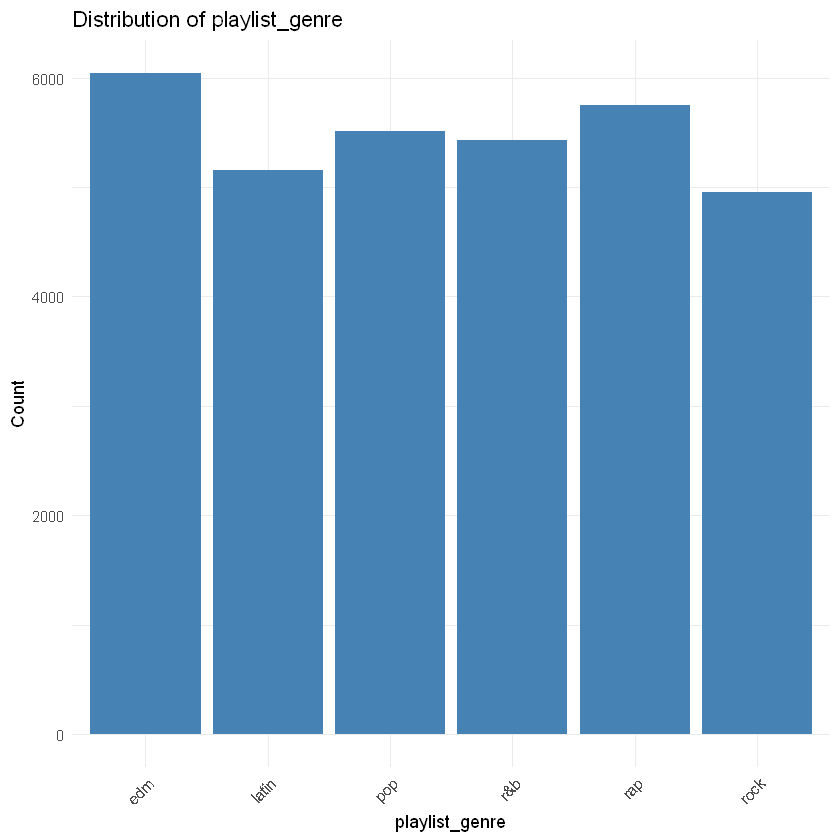

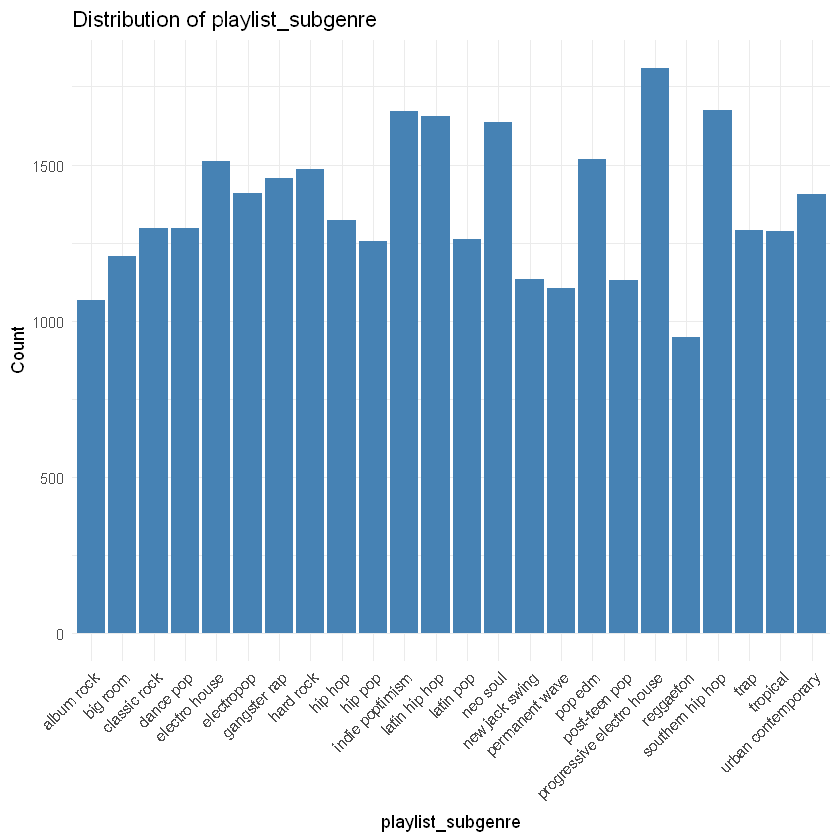

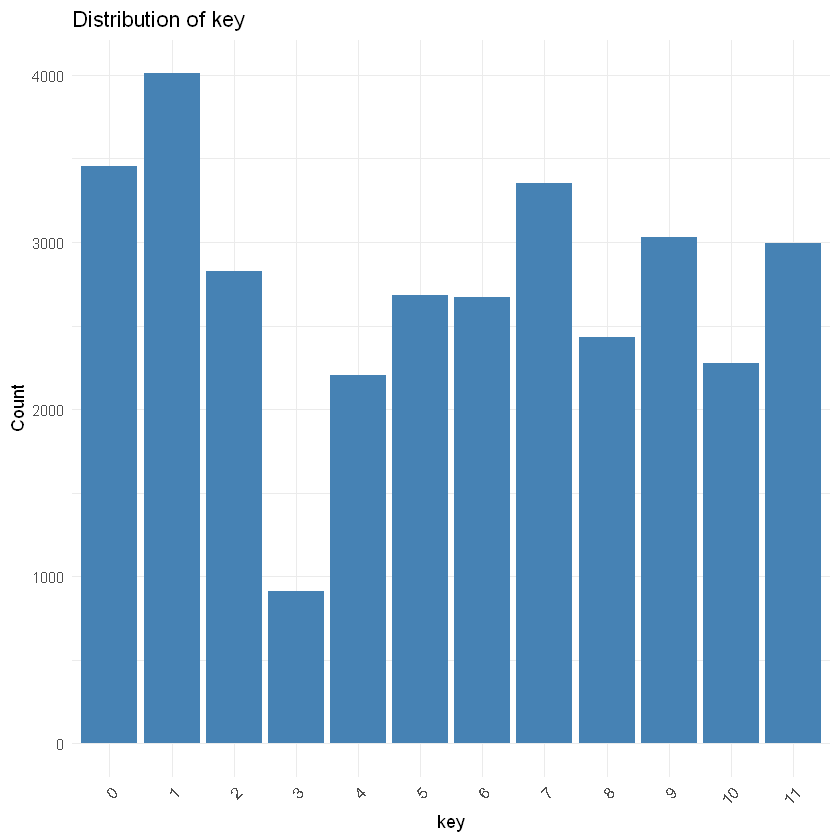

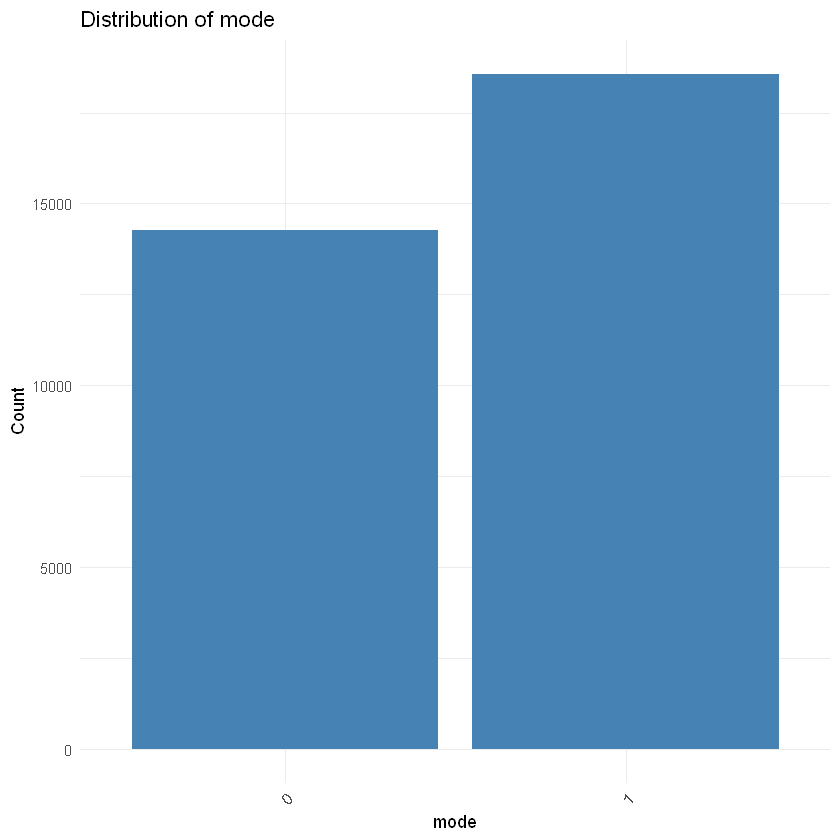

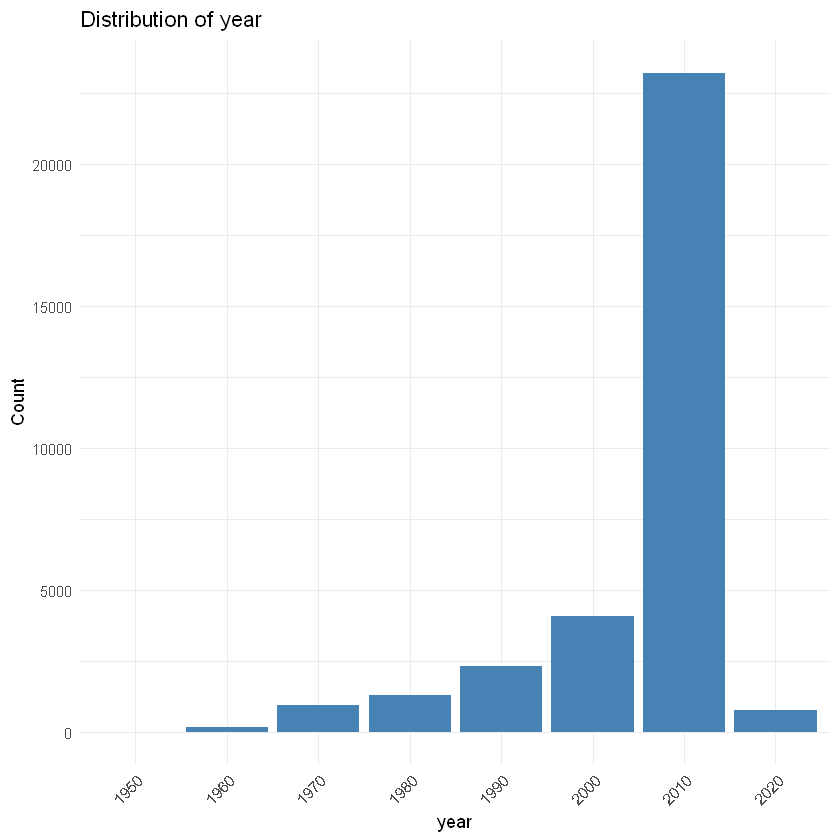

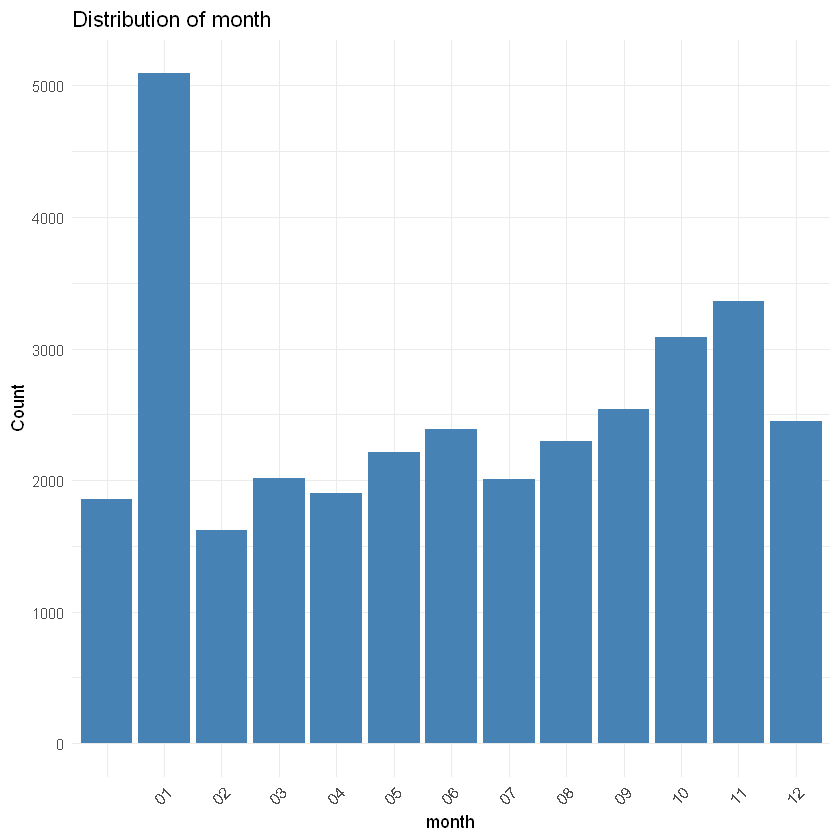

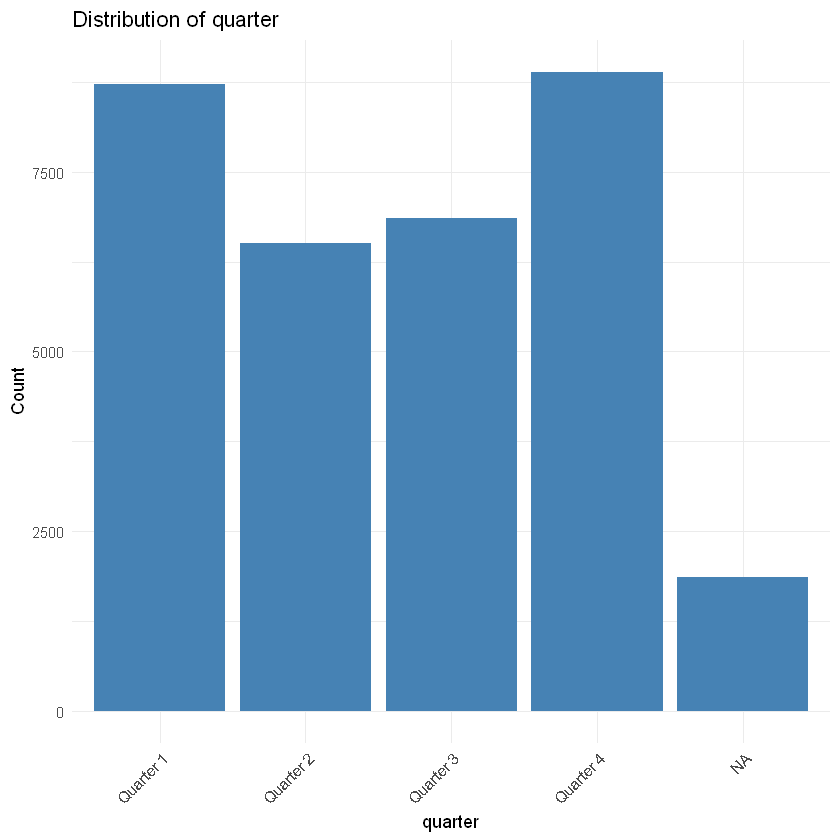

In [23]:
cat_df <- df %>% dplyr::select(where(is.factor))

for (col in names(cat_df)) {
  p <- ggplot(cat_df, aes(x = .data[[col]])) +
    geom_bar(fill = "steelblue") +
    labs(x = col, y = "Count",
         title = paste("Distribution of", col)) +
    theme_minimal() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))
  
  print(p) 
} 

In [24]:
nrow(df[df$track_popularity == 0,])
nrow(df[df$track_popularity == 1,])
nrow(df[df$track_popularity == 2,])

[1] 2703

[1] 575

[1] 387

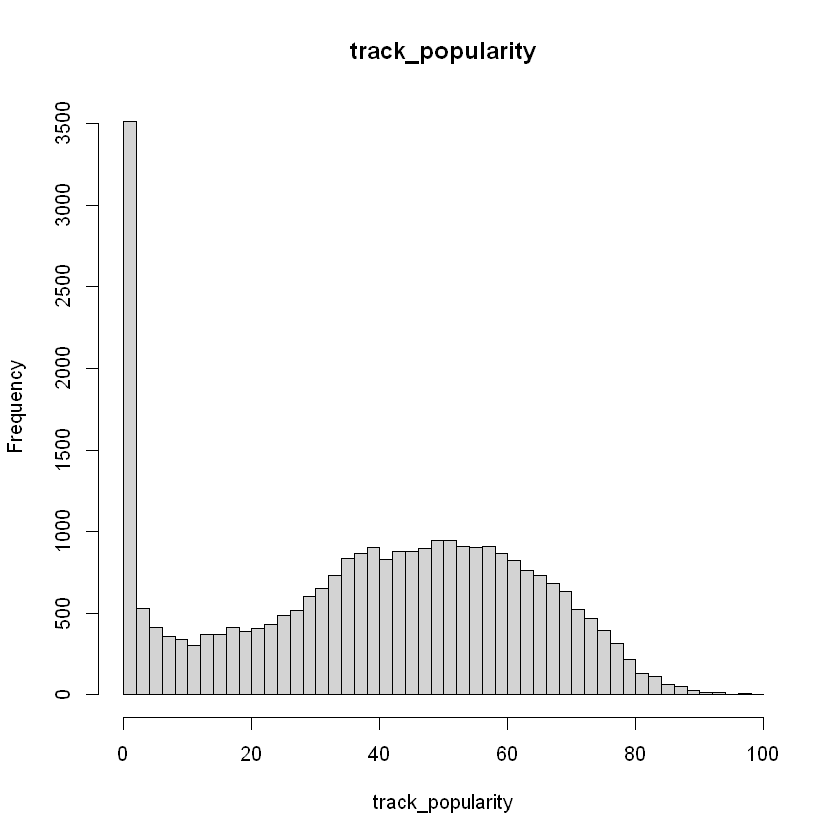

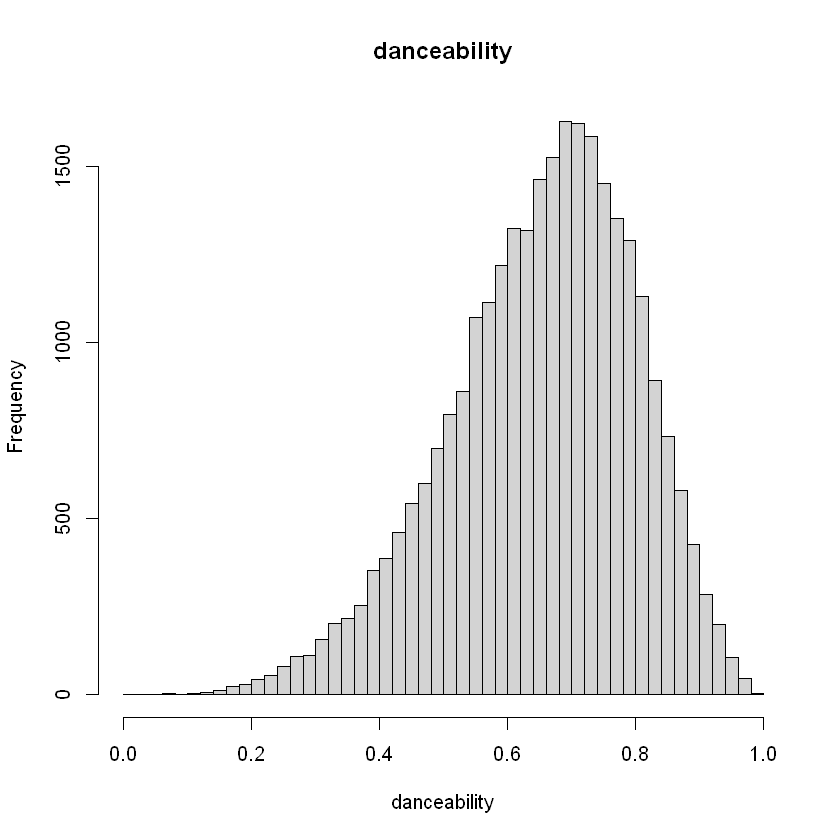

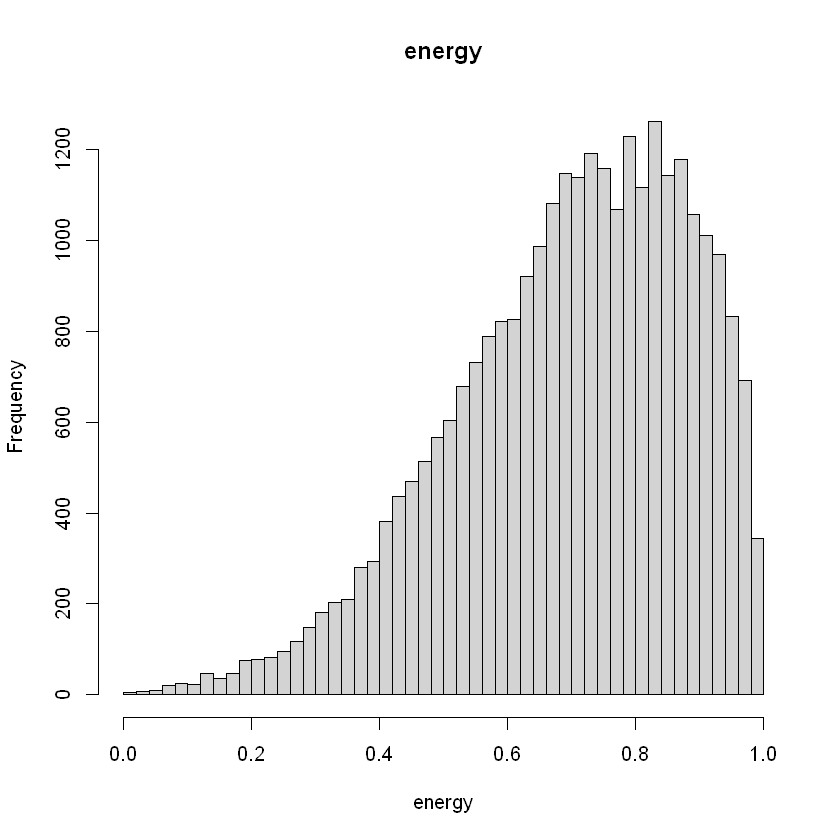

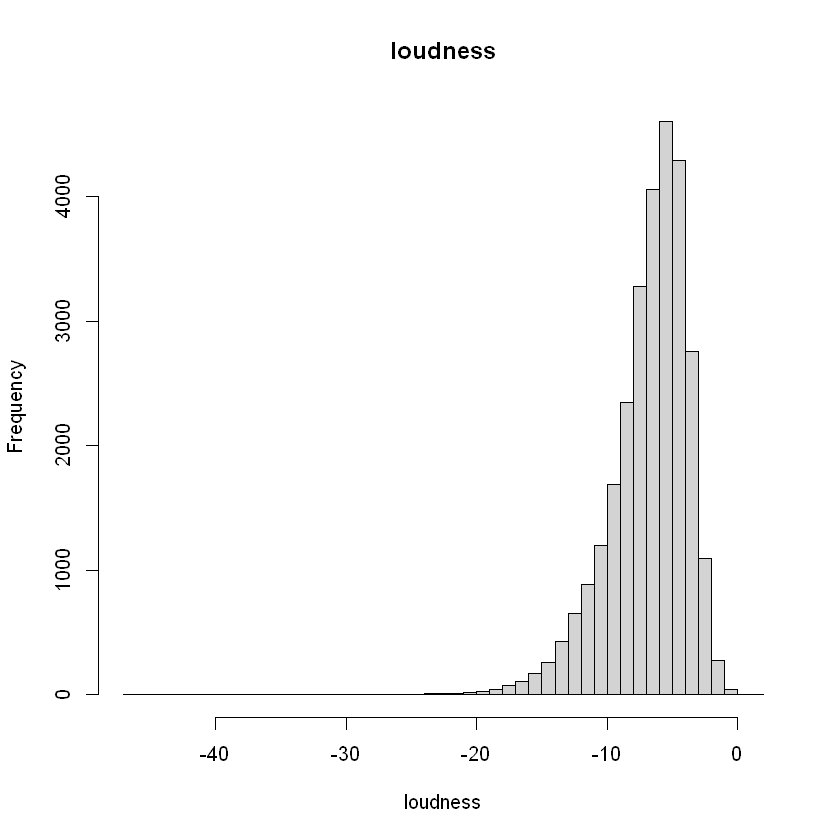

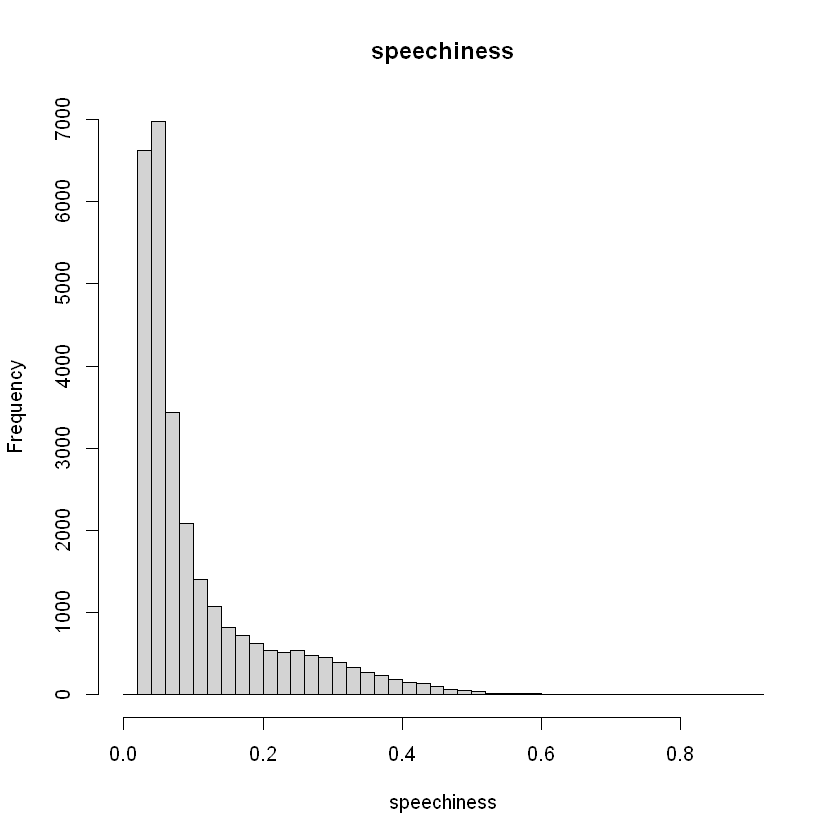

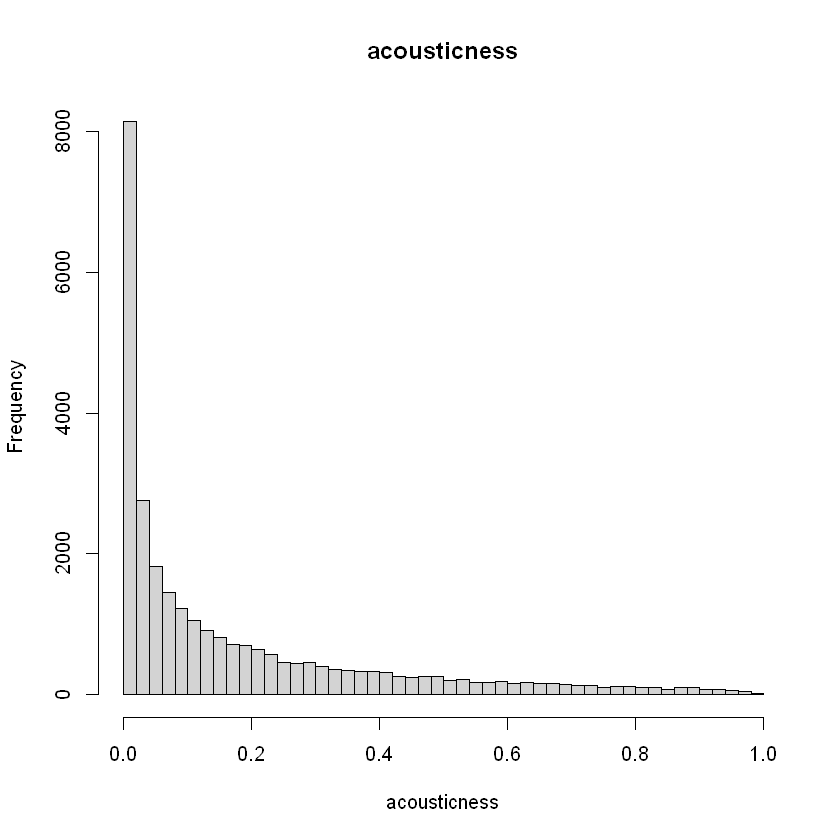

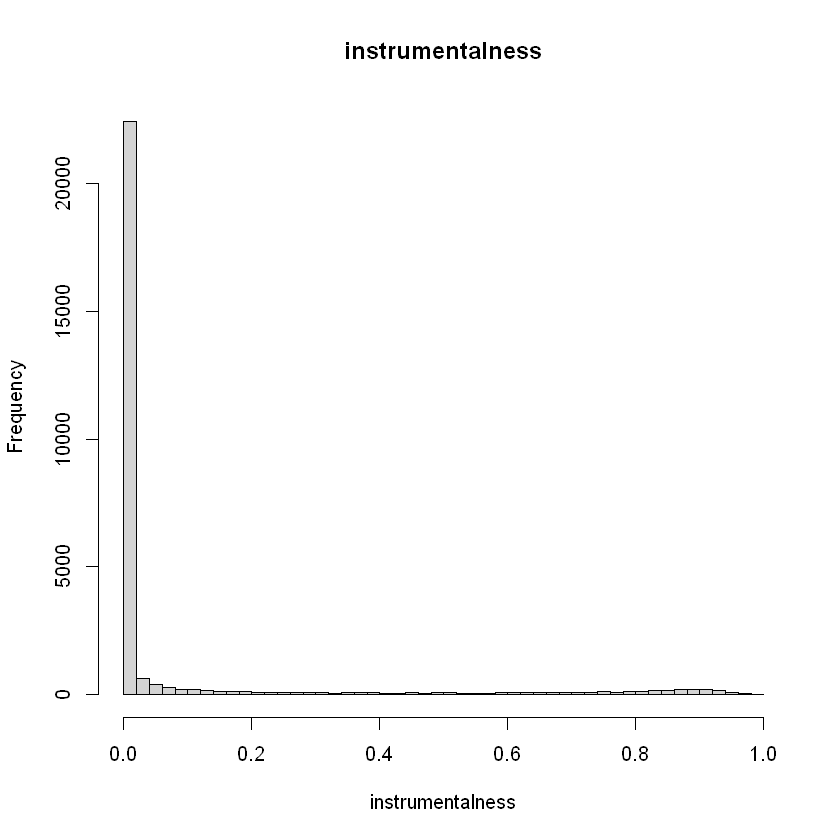

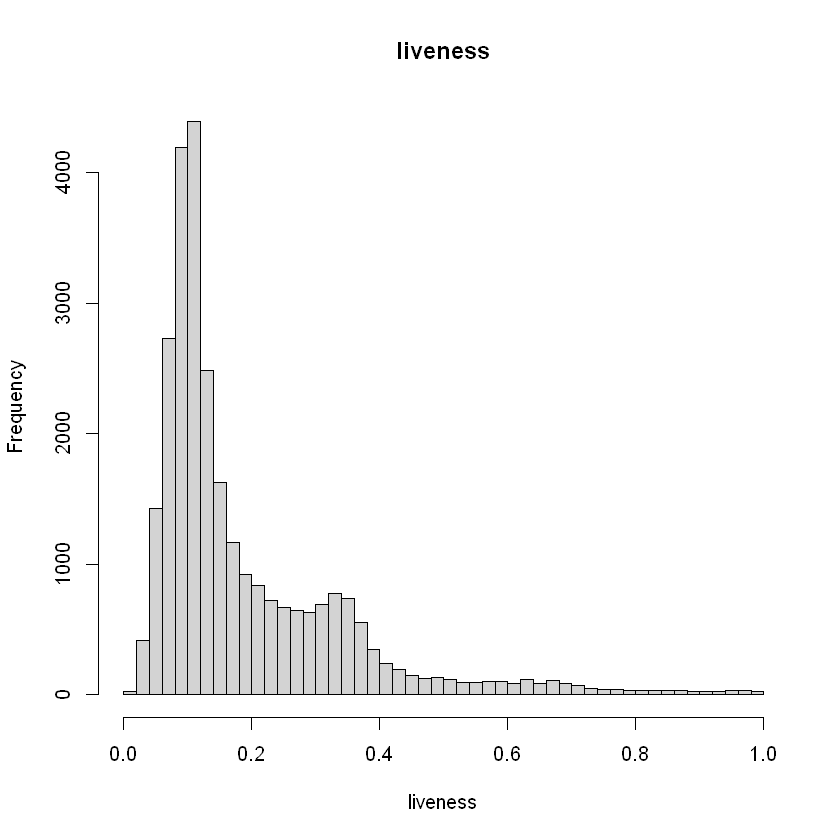

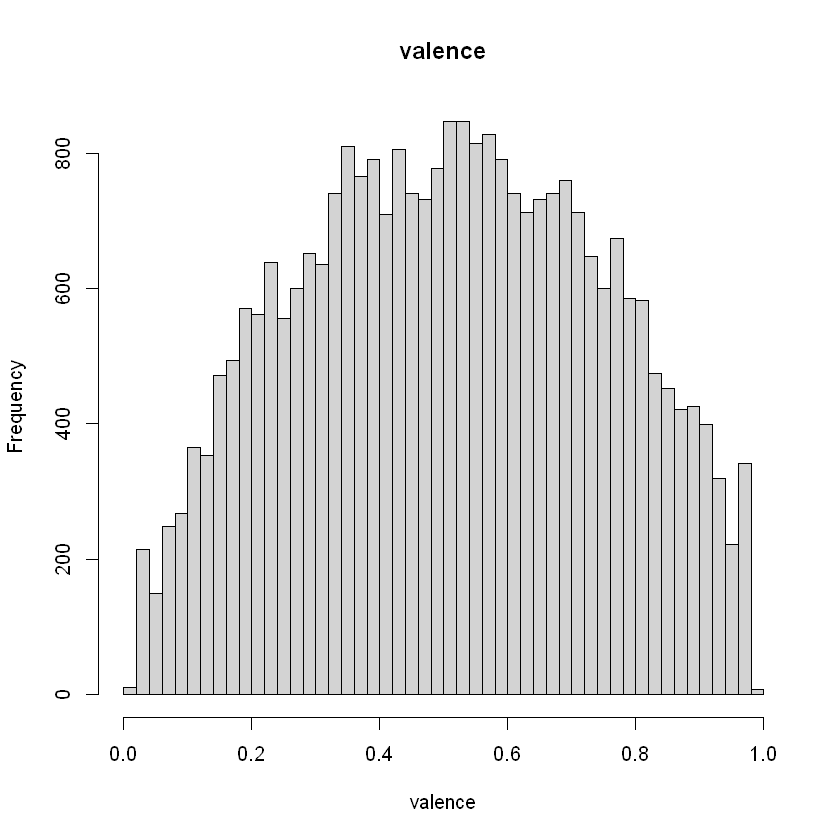

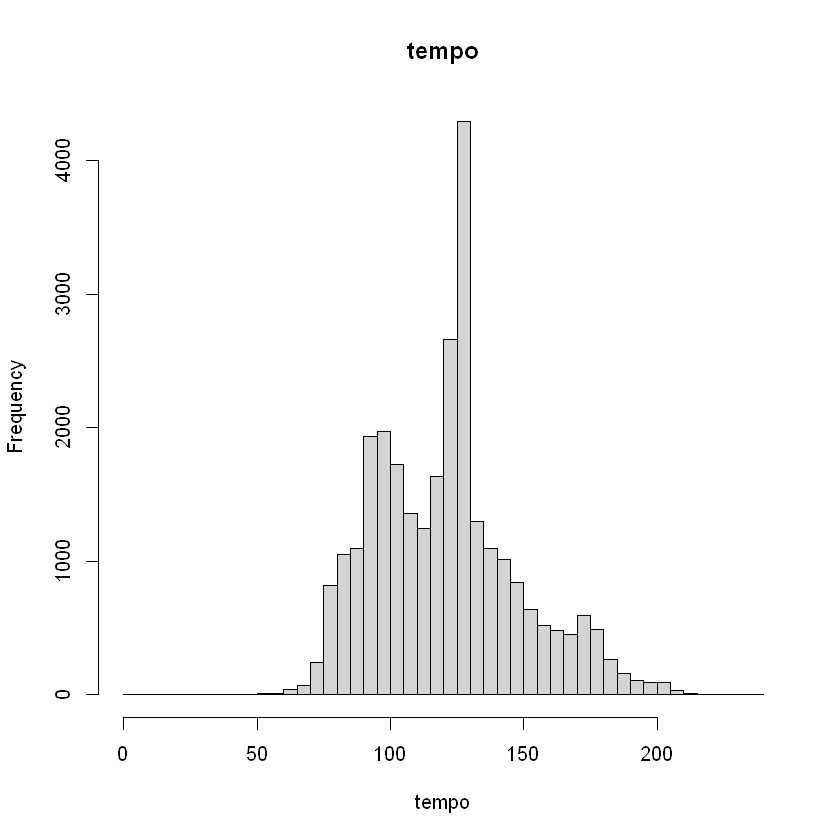

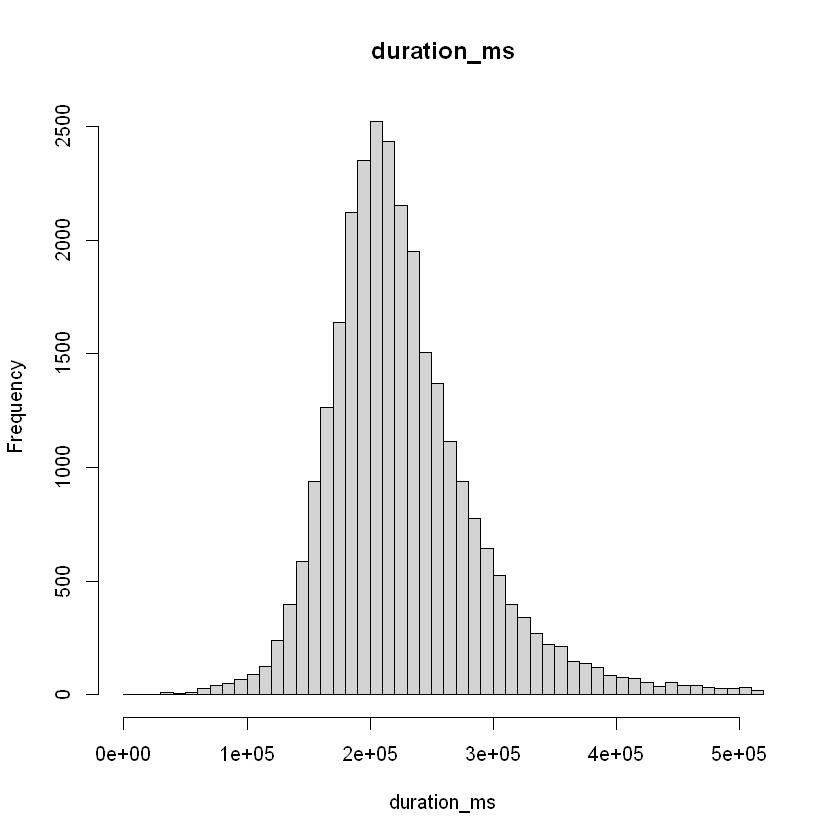

In [25]:
for (col in names(num_df)) {
  hist(num_df[[col]], main = col, xlab = col,breaks = 50)
}

In [26]:
library(moments)
for (col in names(num_df)) {
  skewness_value <- skewness(num_df[[col]], na.rm = TRUE)
  cat("Skewness of", col, ":", skewness_value, "\n")
}

Skewness of track_popularity : -0.2315432 
Skewness of danceability : -0.5060617 
Skewness of energy : -0.6455868 
Skewness of loudness : -1.358801 
Skewness of speechiness : 1.965565 
Skewness of acousticness : 1.575693 
Skewness of instrumentalness : 2.627647 
Skewness of liveness : 2.081978 
Skewness of valence : -0.007881982 
Skewness of tempo : 0.5138545 
Skewness of duration_ms : 1.115681 


In [28]:
cat_df$bool_instrumentalness <- ifelse(df$instrumentalness == 0, "Zero", "Non-Zero")

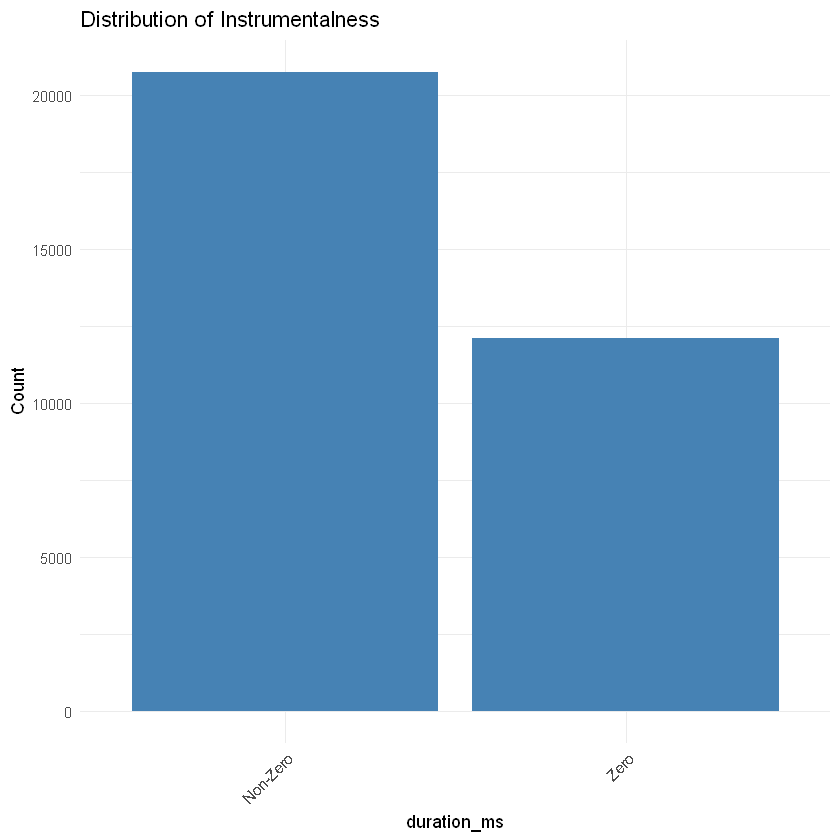

In [29]:
ggplot(cat_df, aes(x = bool_instrumentalness)) +
    geom_bar(fill = "steelblue") +
    labs(x = col, y = "Count",
         title = "Distribution of Instrumentalness" ) +
    theme_minimal() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))

In [30]:
cat_vars <- names(cat_df)
num_vars <- names(num_df)


In [31]:
df$bool_instrumentalness <- ifelse(df$instrumentalness == 0, "Zero", "Non-Zero")

In [32]:
pval_matrix <- matrix(NA, nrow = length(num_vars), ncol = length(cat_vars),
                      dimnames = list(num_vars, cat_vars))
for (cat_col in cat_vars) {
    for (num_col in num_vars){
        formula <- as.formula(paste(num_col, "~", cat_col))
        model <- lm(formula, data = df)
        df.aov <- anova(model)
        pval_matrix[num_col, cat_col] <- df.aov$`Pr(>F)`[1]
    }
}
pval_df <- as.data.frame(pval_matrix)
print(pval_df)

                 playlist_genre playlist_subgenre          key         mode
track_popularity  2.702657e-218      0.000000e+00 1.988223e-05 5.394028e-02
danceability       0.000000e+00      0.000000e+00 8.403977e-74 2.035418e-26
energy             0.000000e+00      0.000000e+00 4.047891e-12 3.844765e-01
loudness           0.000000e+00      0.000000e+00 2.560569e-19 4.733115e-04
speechiness        0.000000e+00      0.000000e+00 4.555300e-69 1.051537e-30
acousticness       0.000000e+00      0.000000e+00 7.614611e-26 8.800345e-02
instrumentalness   0.000000e+00      0.000000e+00 6.346003e-03 2.219468e-01
liveness           1.009326e-55      2.567494e-97 1.298157e-14 3.146865e-01
valence            0.000000e+00      0.000000e+00 2.944886e-16 6.356985e-01
tempo             3.272718e-147     9.858056e-220 1.290336e-05 9.419525e-03
duration_ms       2.955236e-302      0.000000e+00 4.146911e-16 4.613097e-03
                          year         month      quarter bool_instrumentalness
track_po

In [33]:
num_df$sqrt_speechiness <- sqrt(num_df$speechiness)
num_df$sqrt_acousticness <- sqrt(num_df$acousticness)
num_df$sqrt_duration_ms <- sqrt(num_df$duration_ms)
num_df$log_liveness <- log(num_df$liveness + 1)
num_df$cqrt_loudness <- sign(num_df$loudness) * abs(num_df$loudness)^(1/3)
num_df %>% dplyr :: select(-c(speechiness, acousticness, duration_ms, liveness, instrumentalness,loudness)) -> num_df


In [70]:
cat_df$factor_popularity <- ceiling(df$track_popularity/10)

In [71]:
cat_df$factor_popularity <- as.factor(cat_df$factor_popularity)
summary(cat_df$factor_popularity)

0    1    2    3    4    5    6    7    8    9   10 
2703 2714 2012 2579 4166 4697 5020 4518 3084 1088  252

Warning message:
"Use of `num_df[[col]]` is discouraged.
ℹ Use `.data[[col]]` instead."
Warning message:
"Use of `num_df[[col]]` is discouraged.
ℹ Use `.data[[col]]` instead."


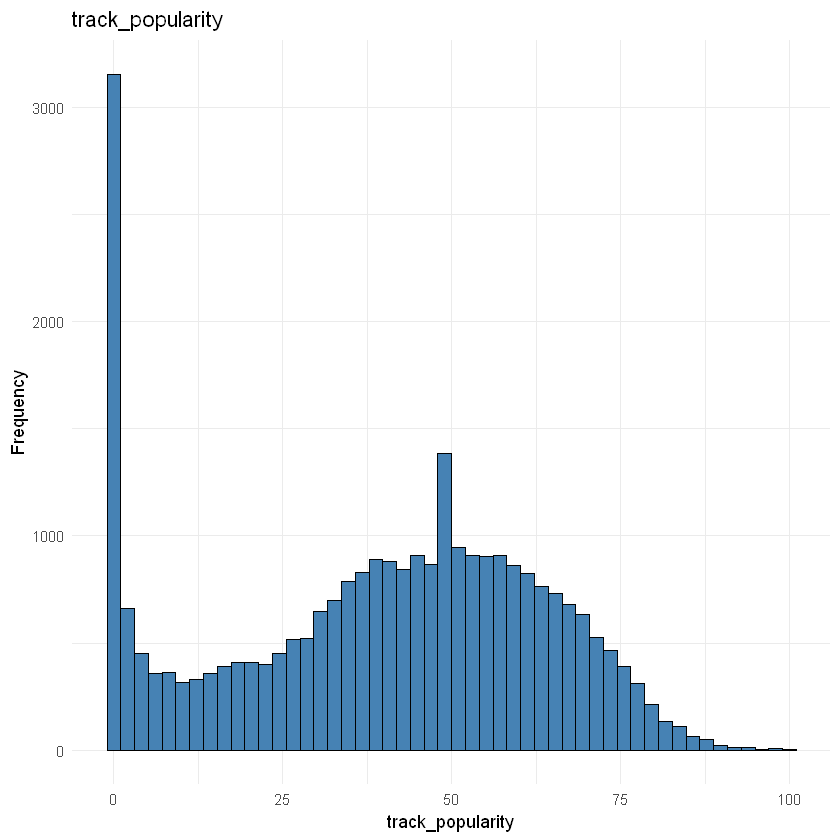

Warning message:
"Use of `num_df[[col]]` is discouraged.
ℹ Use `.data[[col]]` instead."


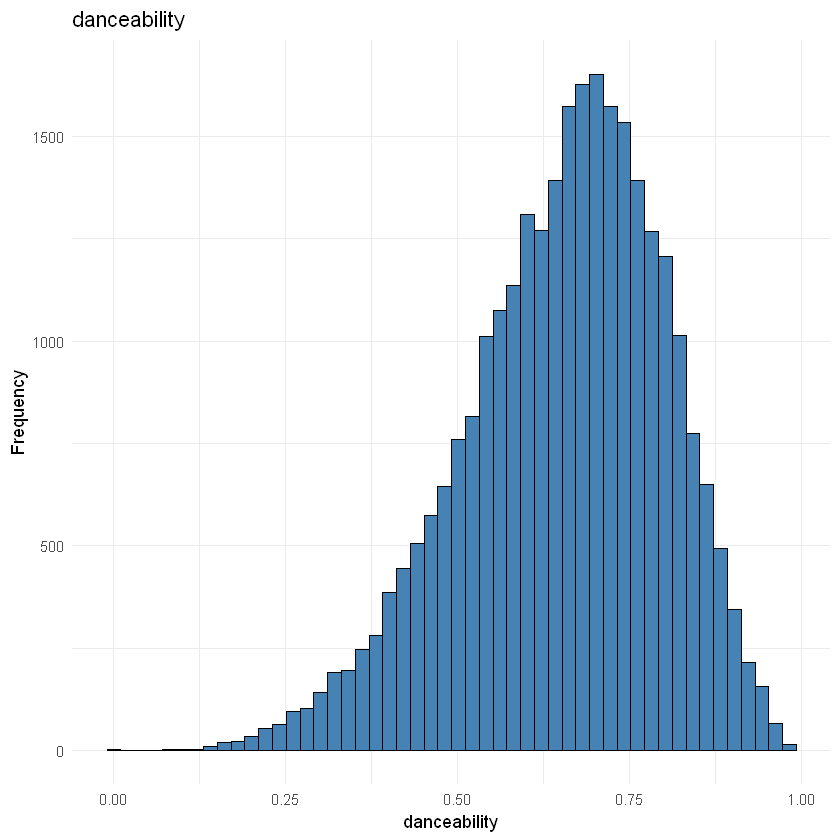

Warning message:
"Use of `num_df[[col]]` is discouraged.
ℹ Use `.data[[col]]` instead."


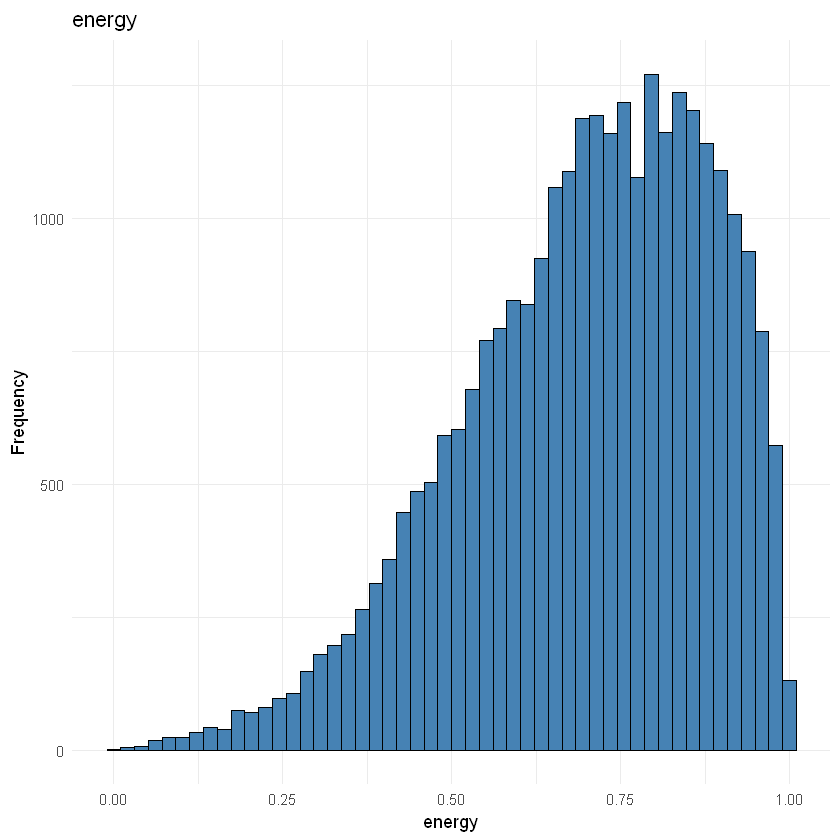

Warning message:
"Use of `num_df[[col]]` is discouraged.
ℹ Use `.data[[col]]` instead."


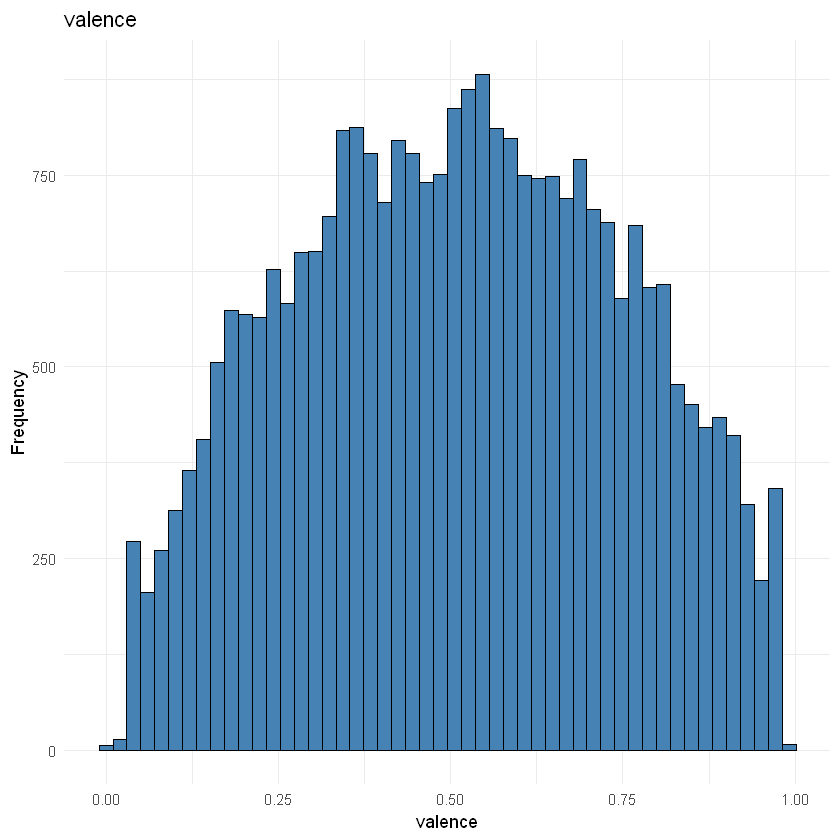

Warning message:
"Use of `num_df[[col]]` is discouraged.
ℹ Use `.data[[col]]` instead."


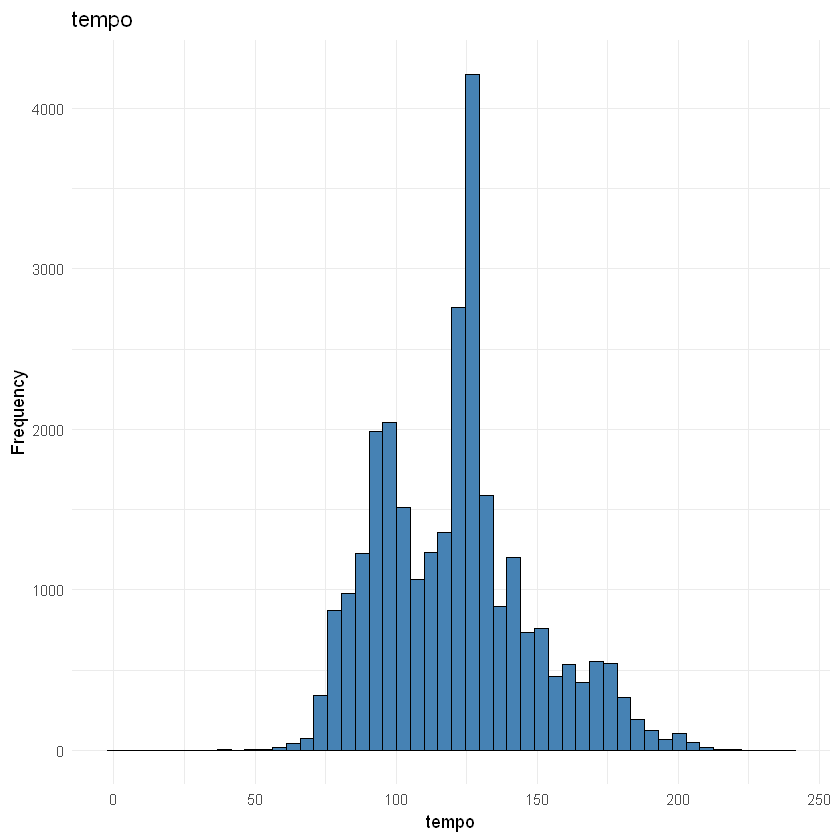

Warning message:
"Use of `num_df[[col]]` is discouraged.
ℹ Use `.data[[col]]` instead."


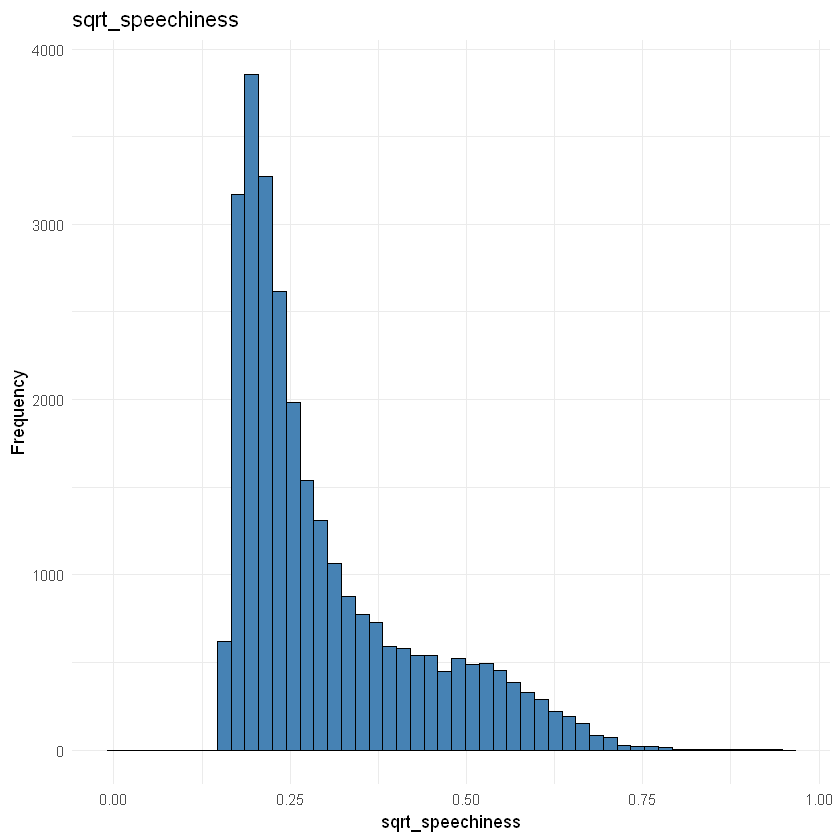

Warning message:
"Use of `num_df[[col]]` is discouraged.
ℹ Use `.data[[col]]` instead."


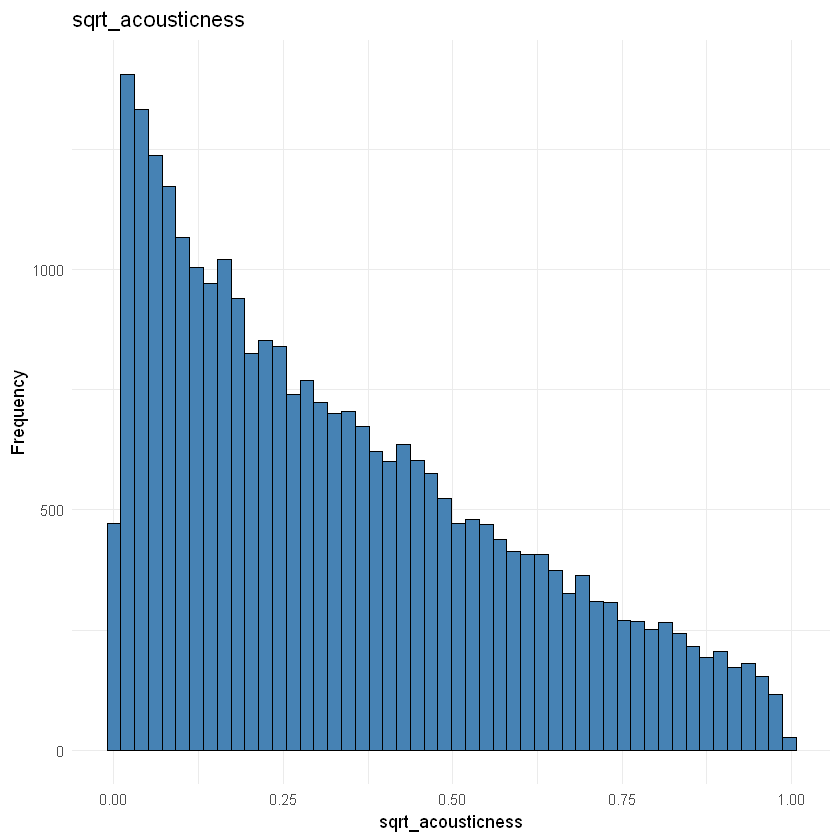

Warning message:
"Use of `num_df[[col]]` is discouraged.
ℹ Use `.data[[col]]` instead."


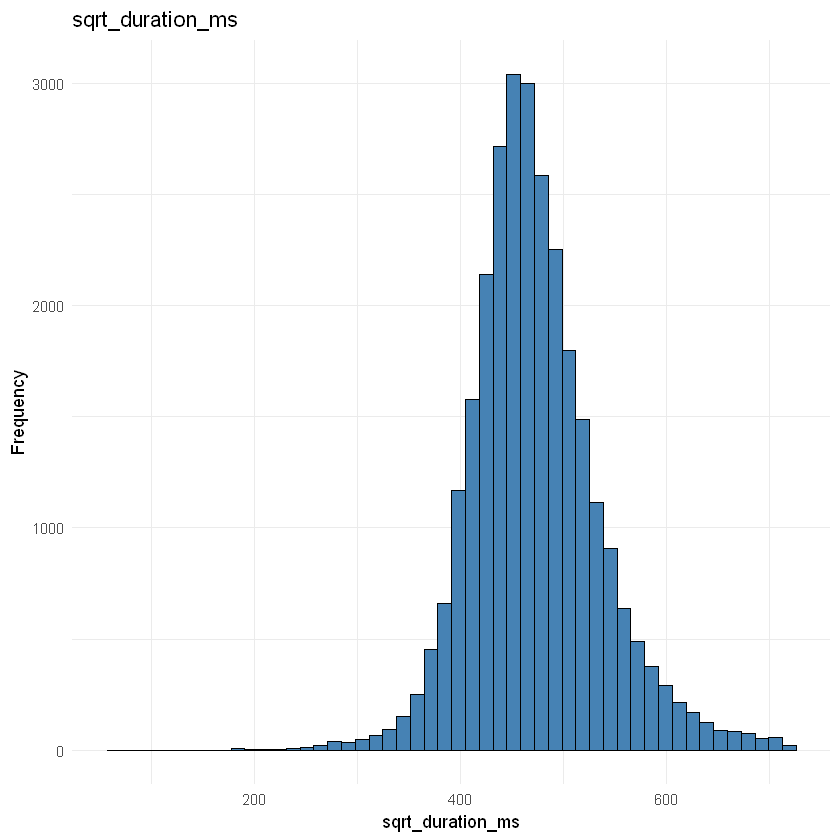

Warning message:
"Use of `num_df[[col]]` is discouraged.
ℹ Use `.data[[col]]` instead."


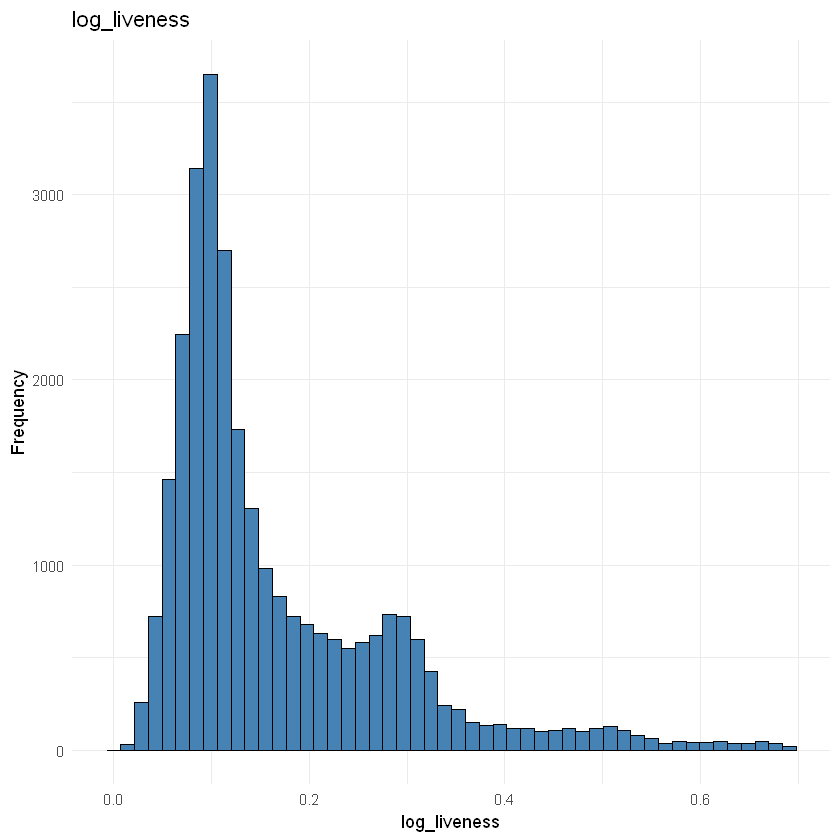

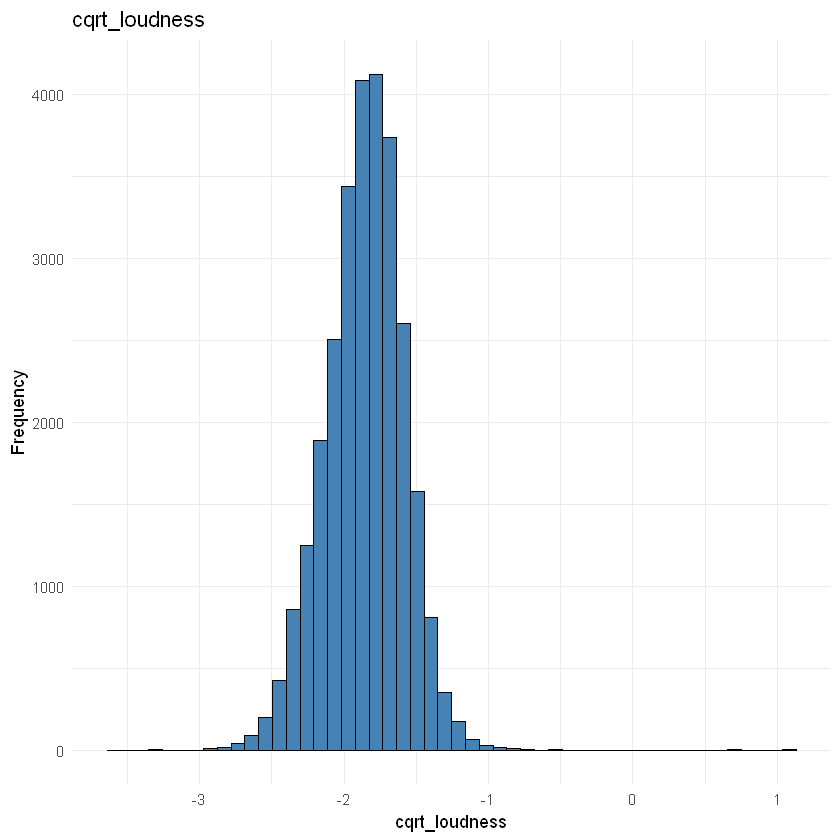

In [34]:
for (col in names(num_df)) {
  p <- ggplot(num_df, aes(x = num_df[[col]])) +
    geom_histogram(bins = 50,fill = "steelblue",color = "black") +
    theme_minimal() +
    labs(title = col, x = col, y = "Frequency")
    print(p)
}

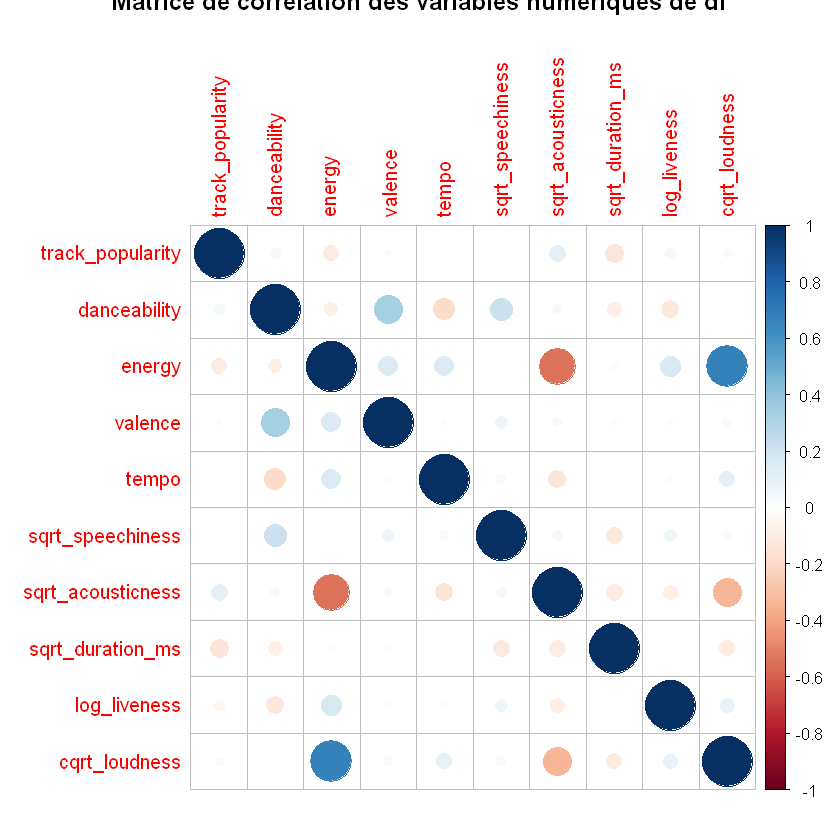

In [35]:
corr <- cor(num_df)
corrplot(corr, title = "Matrice de corrélation des variables numériques de df")

In [36]:
results <- data.frame()

for (i in 1:(ncol(cat_df) - 1)) {
  for (j in (i + 1):ncol(cat_df)) {
    test <- chisq.test(table(cat_df[[i]], cat_df[[j]]))
    
    results <- rbind(results, data.frame(
      var1    = names(cat_df)[i],
      var2    = names(cat_df)[j],
      chi_sq  = round(test$statistic, 3),
      p_value = test$p.value
    ))
  }
}
print(results)

Warning message in chisq.test(table(cat_df[[i]], cat_df[[j]])):
"Chi-squared approximation may be incorrect"
Warning message in chisq.test(table(cat_df[[i]], cat_df[[j]])):
"Chi-squared approximation may be incorrect"
Warning message in chisq.test(table(cat_df[[i]], cat_df[[j]])):
"Chi-squared approximation may be incorrect"
Warning message in chisq.test(table(cat_df[[i]], cat_df[[j]])):
"Chi-squared approximation may be incorrect"
Warning message in chisq.test(table(cat_df[[i]], cat_df[[j]])):
"Chi-squared approximation may be incorrect"
Warning message in chisq.test(table(cat_df[[i]], cat_df[[j]])):
"Chi-squared approximation may be incorrect"
Warning message in chisq.test(table(cat_df[[i]], cat_df[[j]])):
"Chi-squared approximation may be incorrect"
Warning message in chisq.test(table(cat_df[[i]], cat_df[[j]])):
"Chi-squared approximation may be incorrect"


                         var1                  var2     chi_sq       p_value
X-squared      playlist_genre     playlist_subgenre 164165.000  0.000000e+00
X-squared1     playlist_genre                   key    943.906 3.957663e-162
X-squared2     playlist_genre                  mode    516.795 1.891477e-109
X-squared3     playlist_genre                  year  12000.737  0.000000e+00
X-squared4     playlist_genre                 month   1836.393  0.000000e+00
X-squared5     playlist_genre               quarter    231.407  8.223388e-41
X-squared6     playlist_genre bool_instrumentalness   2496.988  0.000000e+00
X-squared7  playlist_subgenre                   key   1445.238 5.269916e-166
X-squared8  playlist_subgenre                  mode    758.696 1.852956e-145
X-squared9  playlist_subgenre                  year  20934.367  0.000000e+00
X-squared10 playlist_subgenre                 month   3795.826  0.000000e+00
X-squared11 playlist_subgenre               quarter   1040.380 2.522739e-173

In [37]:
df.acp <- PCA(num_df,scale.unit = TRUE)

Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the ggpubr package.
  Please report the issue at <https://github.com/kassambara/ggpubr/issues>."
Warning message:
"`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the factoextra package.
  Please report the issue at <https://github.com/kassambara/factoextra/issues>."


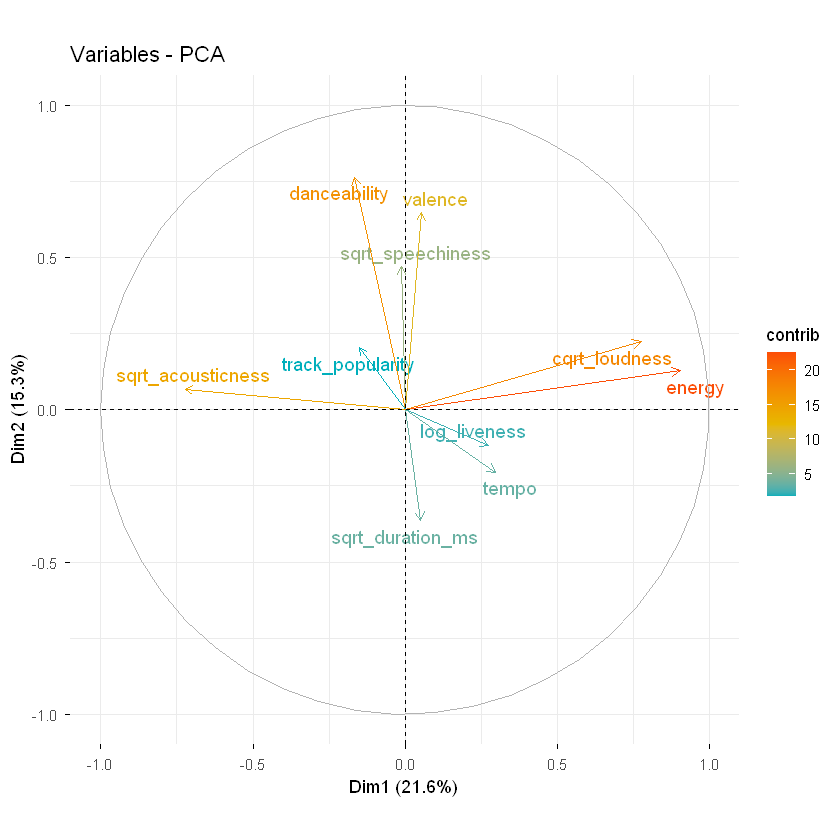

In [38]:
fviz_pca_var(df.acp, col.var = "contrib",gradient.cols = c("#00AFBB", "#E7B800", "#FC4E07"),repel = TRUE)

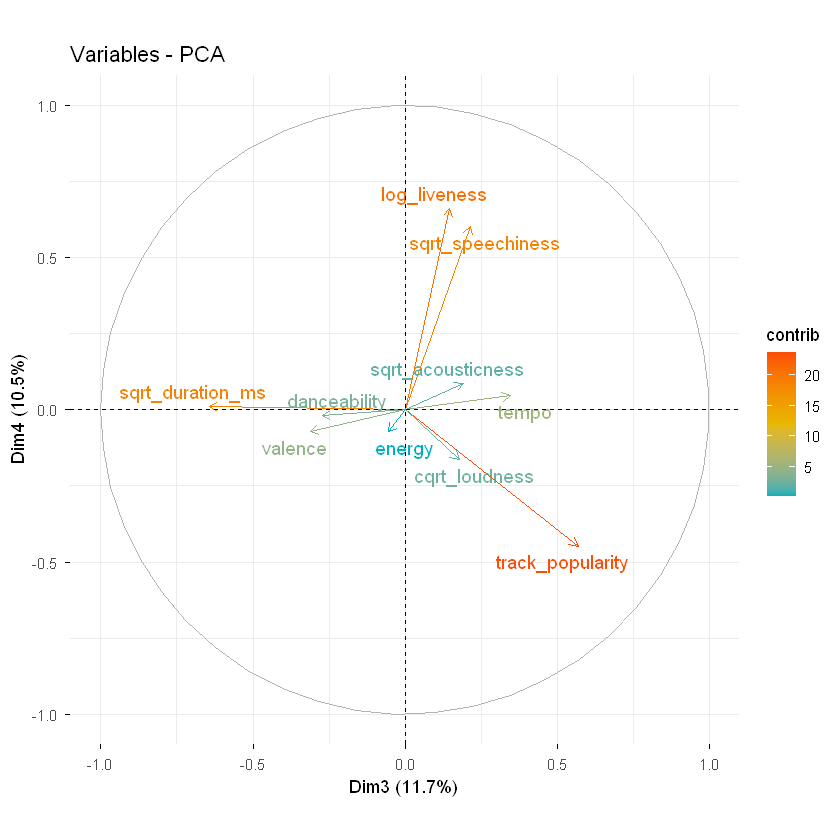

In [39]:
fviz_pca_var(df.acp, col.var = "contrib",gradient.cols = c("#00AFBB", "#E7B800", "#FC4E07"),axes= c(3,4),repel = TRUE)

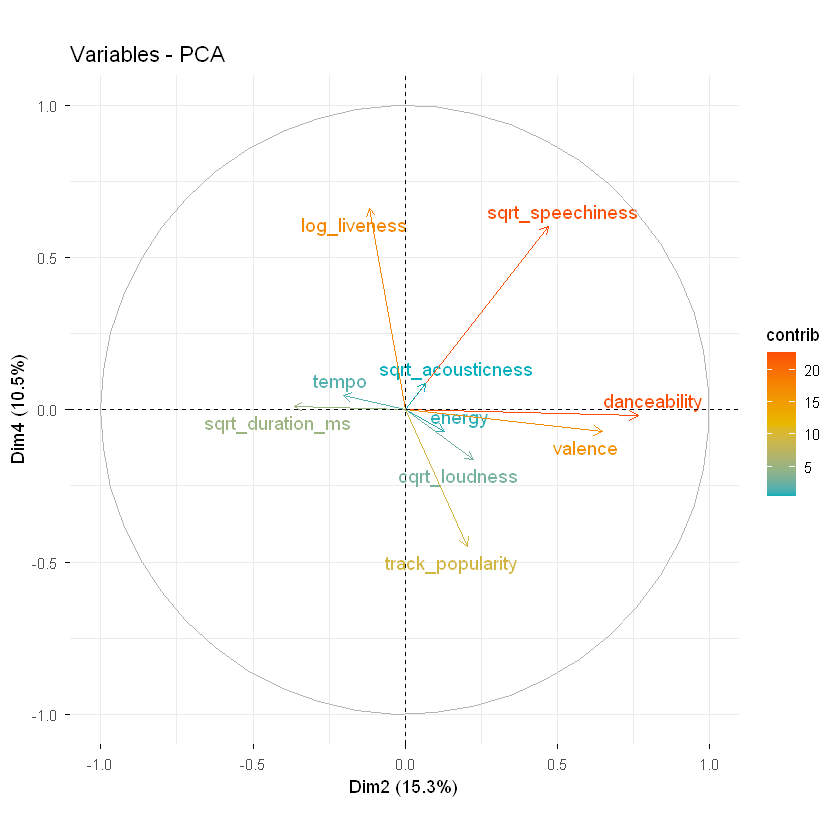

In [105]:
fviz_pca_var(df.acp, col.var = "contrib",gradient.cols = c("#00AFBB", "#E7B800", "#FC4E07"),axes= c(2,4),repel = TRUE)

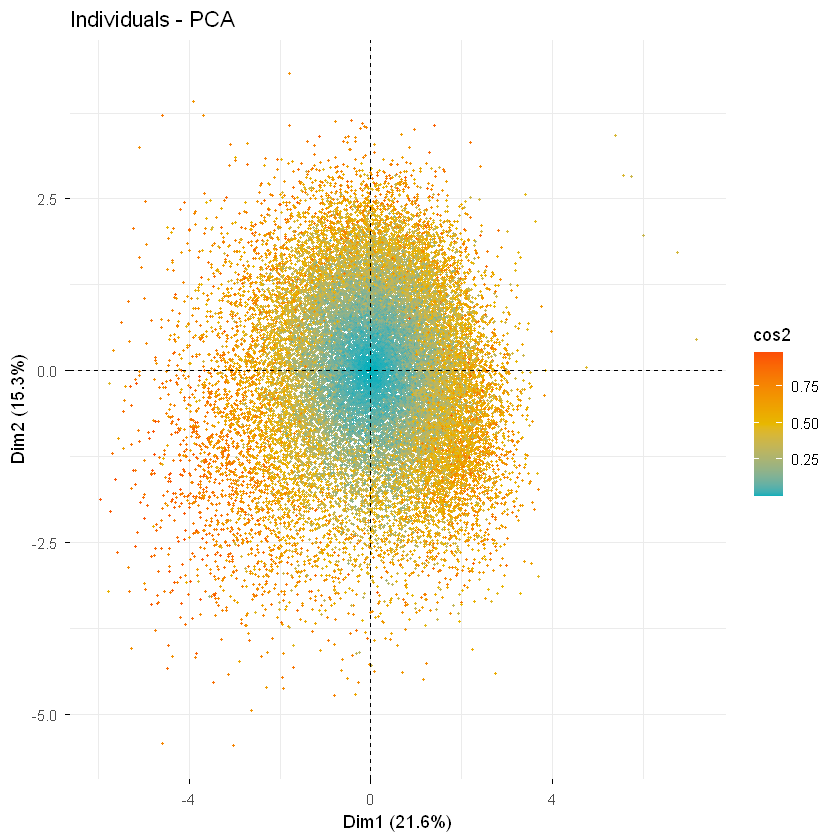

In [40]:
fviz_pca_ind(df.acp,col.ind = "cos2",label='none',gradient.cols = c("#00AFBB", "#E7B800", "#FC4E07"),pointsize = 0.5)

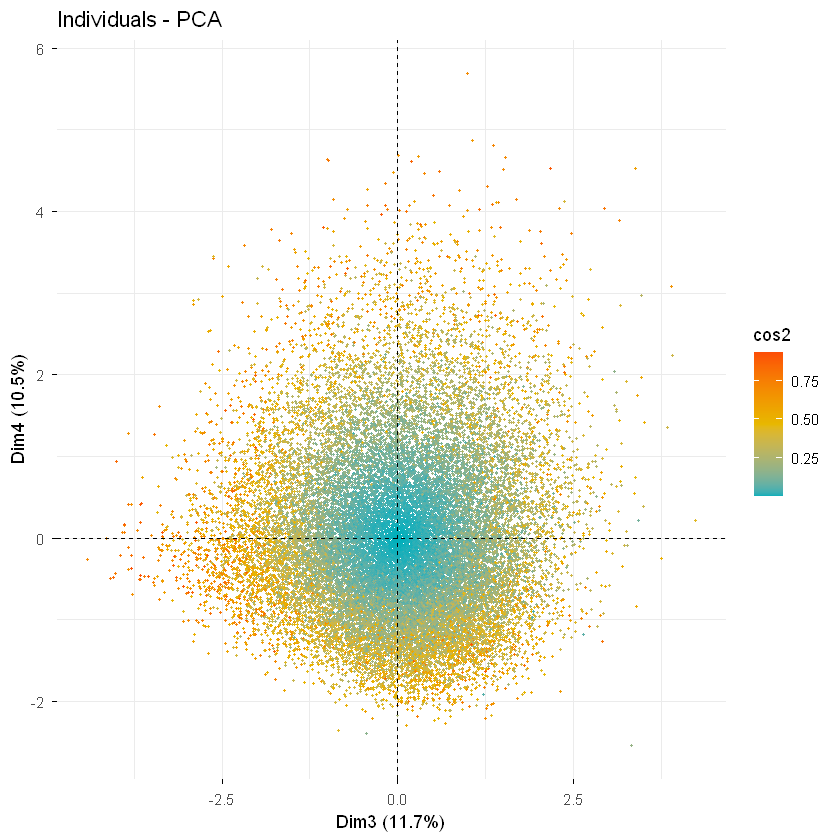

In [41]:
fviz_pca_ind(df.acp,col.ind = "cos2",label='none',gradient.cols = c("#00AFBB", "#E7B800", "#FC4E07"),pointsize = 0.5,axes = c(3,4))

Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."


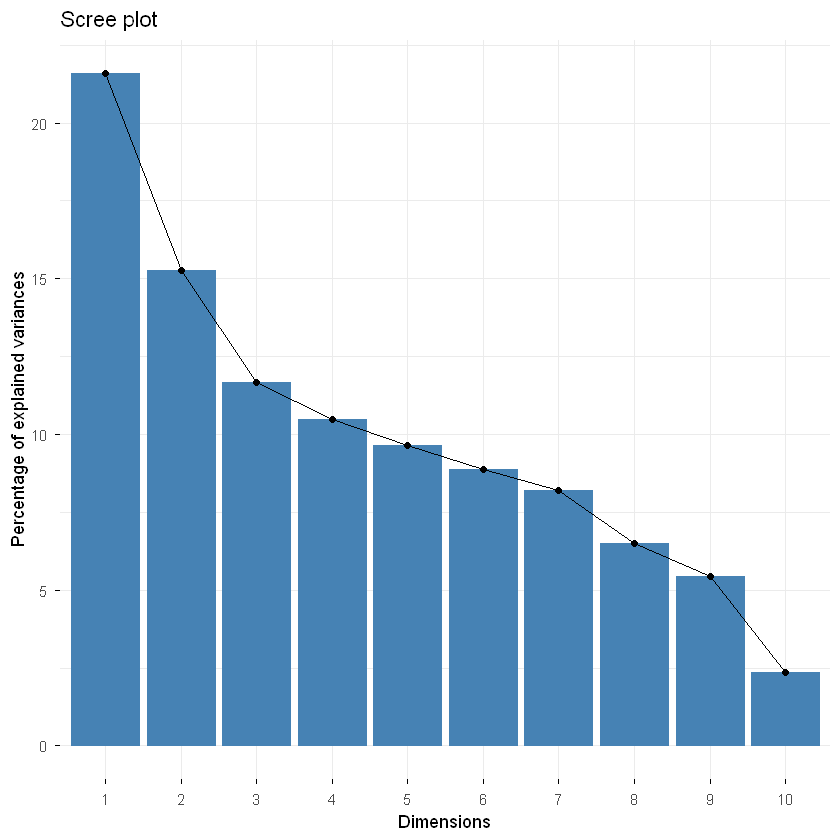

In [42]:
fviz_eig(df.acp)

In [43]:
genre_num_df <- df %>% dplyr :: select(playlist_genre, where(is.numeric)) %>% na.omit()
genre_num_df$playlist_genre <- as.factor(genre_num_df$playlist_genre)
df.lda <- lda(playlist_genre ~ ., data = genre_num_df)
df.lda.pred <- predict(df.lda)

In [44]:
fviz_pca_ind(df.acp, col.ind = df.lda.pred$class,label='none',pointsize = 0.5)

ERROR: Error in fviz(X, element = "ind", axes = axes, geom = geom.ind, habillage = habillage, : The length of color variableshould be the same as the number of rows in the data.


In [45]:
fviz_pca_ind(df.acp, col.ind = df$playlist_genre,label='none',pointsize = 0.5)

ERROR: Error in fviz(X, element = "ind", axes = axes, geom = geom.ind, habillage = habillage, : The length of color variableshould be the same as the number of rows in the data.


In [46]:
nlevels(df$playlist_subgenre)

[1] 24

In [47]:
table(cat_df)

, , key = 0, mode = 0, year = 1950, month = , quarter = Quarter 1, bool_instrumentalness = Non-Zero

              playlist_subgenre
playlist_genre album rock big room classic rock dance pop electro house
         edm            0        0            0         0             0
         latin          0        0            0         0             0
         pop            0        0            0         0             0
         r&b            0        0            0         0             0
         rap            0        0            0         0             0
         rock           0        0            0         0             0
              playlist_subgenre
playlist_genre electropop gangster rap hard rock hip hop hip pop
         edm            0            0         0       0       0
         latin          0            0         0       0       0
         pop            0            0         0       0       0
         r&b            0            0         0       0       0
      

Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."


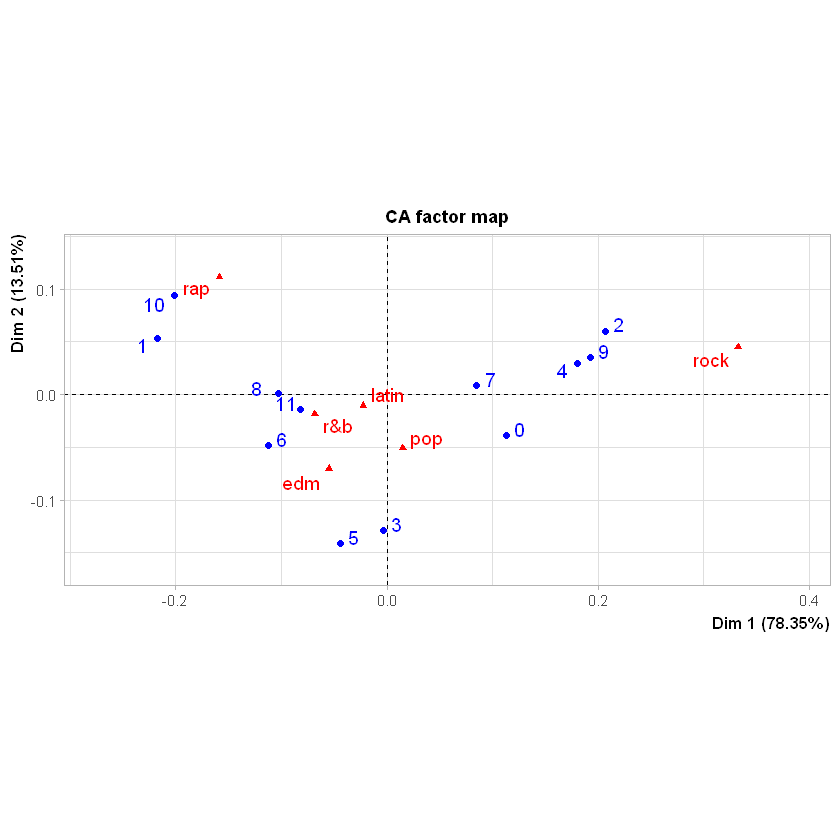

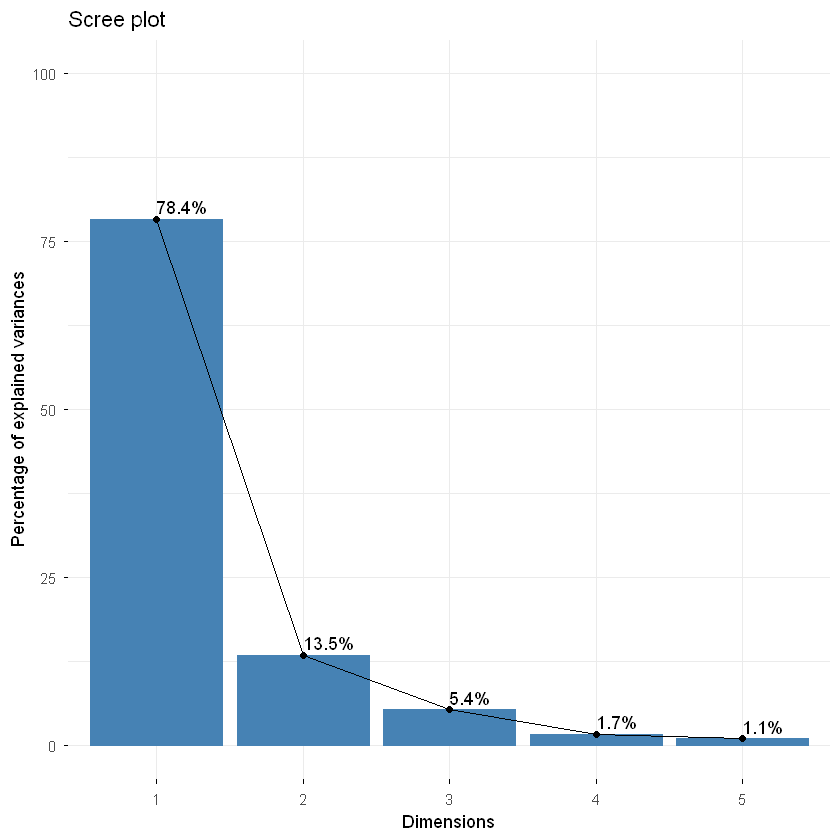

In [48]:
table.key_genre <- table(cat_df$key, cat_df$playlist_genre)
df.ca.key_genre <- CA(table.key_genre, graph = TRUE)
fviz_screeplot(df.ca.key_genre, addlabels = TRUE, ylim = c(0, 100))

Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."


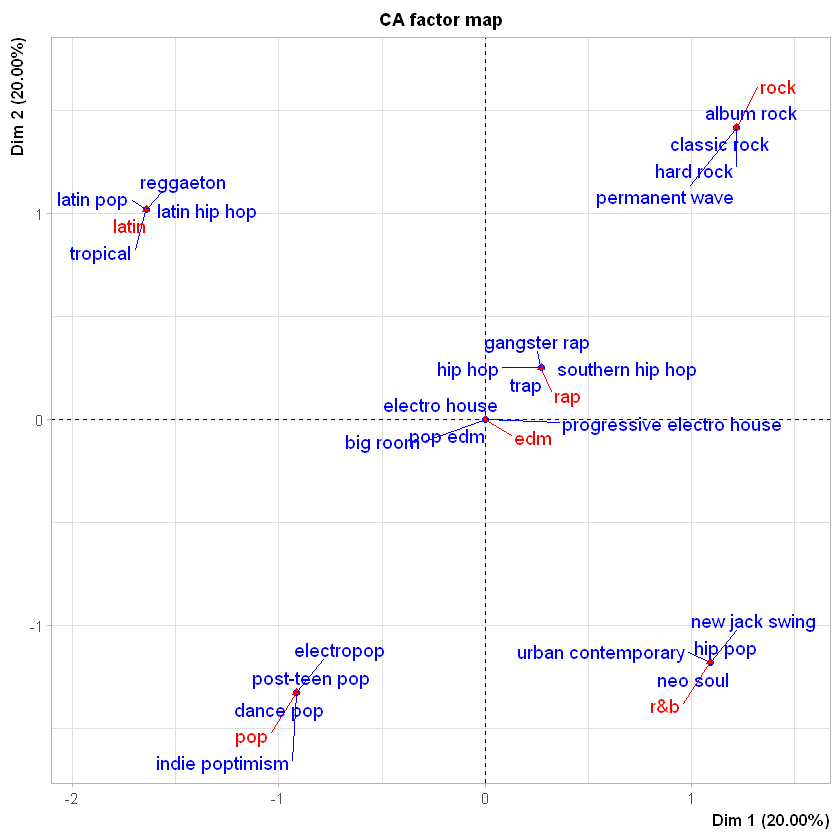

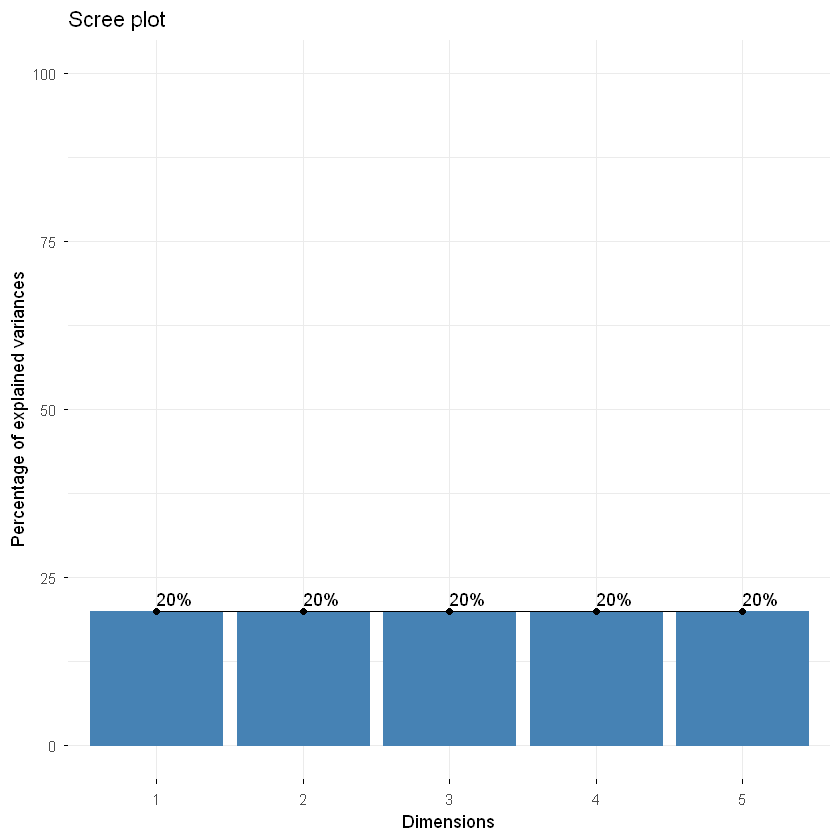

In [49]:
table.subgenre_genre <- table(cat_df$playlist_subgenre, cat_df$playlist_genre)
df.ca.subgenre_genre <- CA(table.subgenre_genre, graph = TRUE)
fviz_screeplot(df.ca.subgenre_genre, addlabels = TRUE, ylim = c(0, 100))

Warning message:
"ggrepel: 4 unlabeled data points (too many overlaps). Consider increasing max.overlaps"
Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."


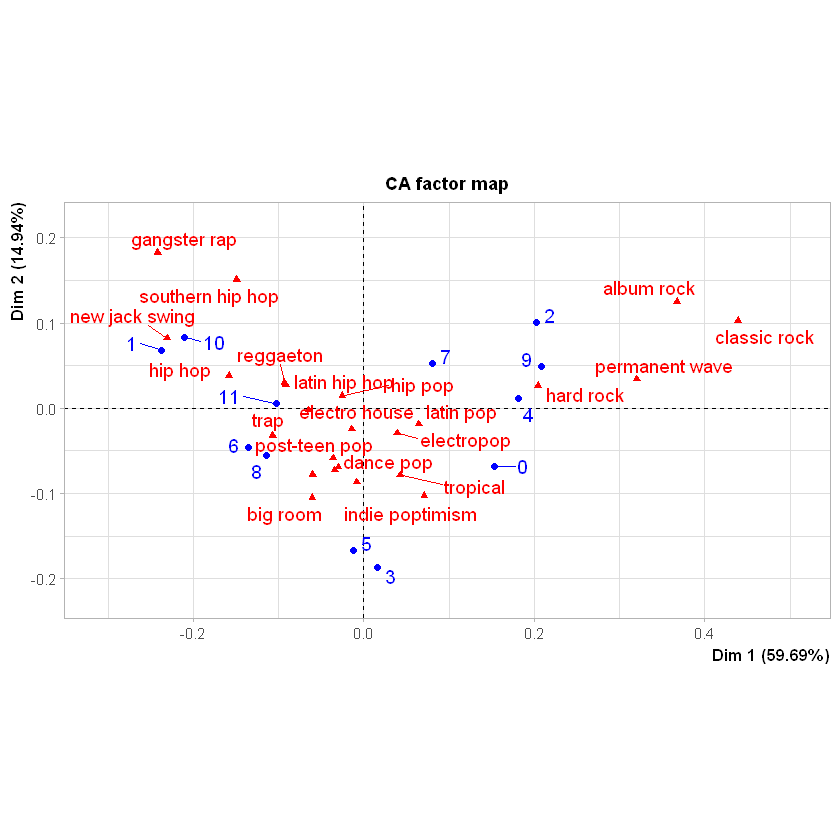

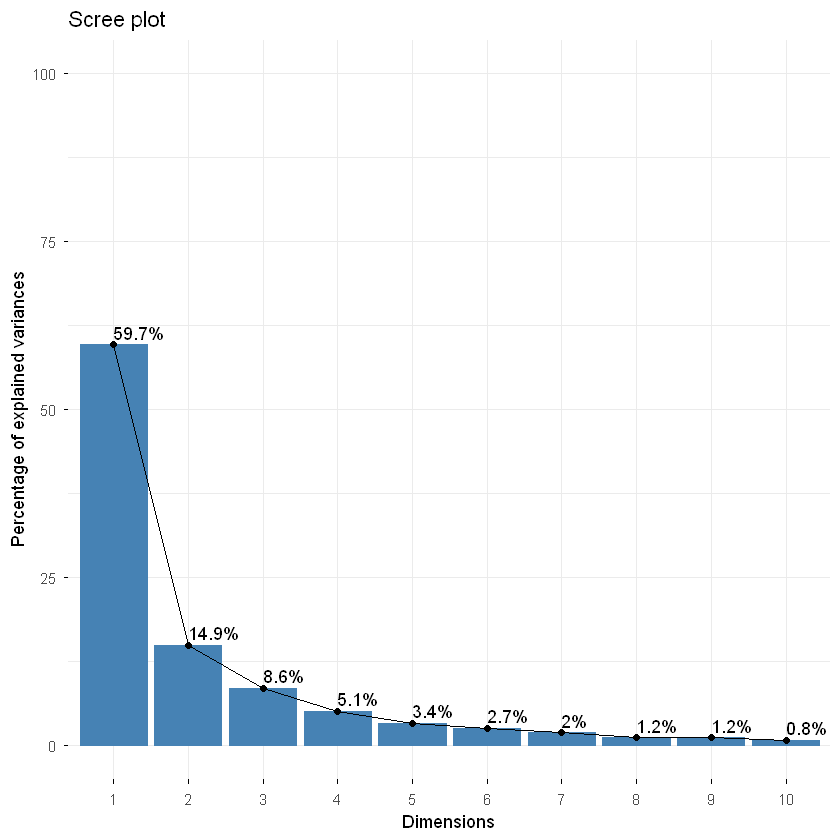

In [50]:
table.key_subgenre <- table(cat_df$key, cat_df$playlist_subgenre)
df.ca.key_subgenre <- CA(table.key_subgenre, graph = TRUE)
fviz_screeplot(df.ca.key_subgenre, addlabels = TRUE, ylim = c(0, 100),repel = TRUE)

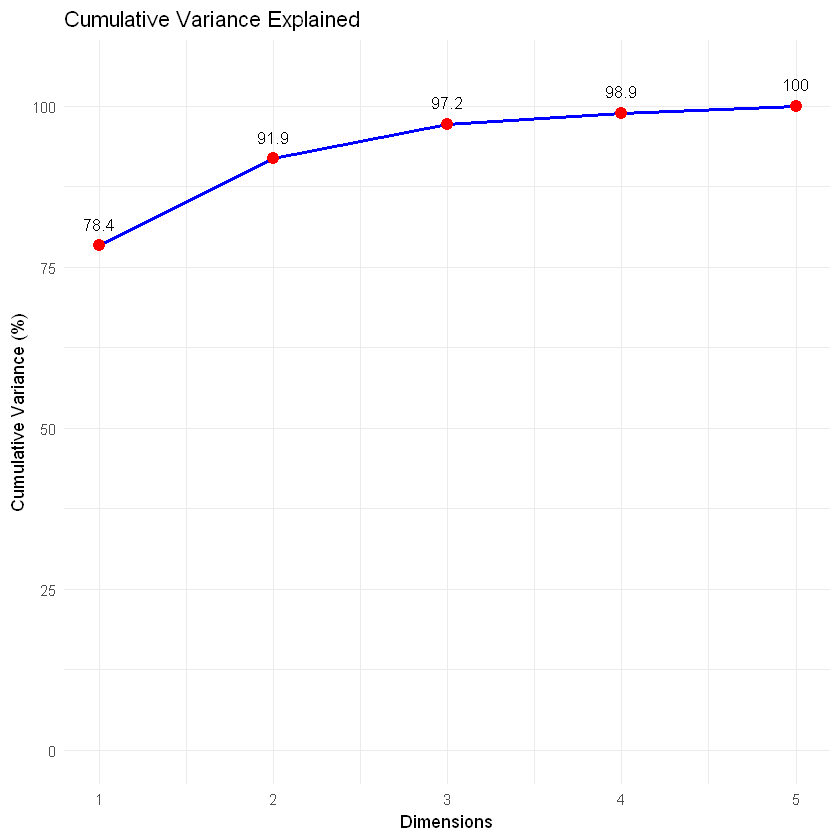

In [51]:
eig.key_genre <- as.data.frame(get_eig(df.ca.key_genre))
eig.key_genre$dimension <- 1:nrow(eig.key_genre)


ggplot(eig.key_genre, aes(x = dimension, y = cumulative.variance.percent)) +
  geom_line(color = "blue", linewidth = 1) + 
  geom_point(color = "red", size = 3) +
  geom_text(aes(label = round(cumulative.variance.percent, 1)), 
            vjust = -1.2, 
            size = 3.5) +
  scale_x_continuous(breaks = eig.key_genre$dimension) + 
  labs(title = "Cumulative Variance Explained",
       x = "Dimensions",
       y = "Cumulative Variance (%)") +
  theme_minimal() +
  ylim(0, 105) 

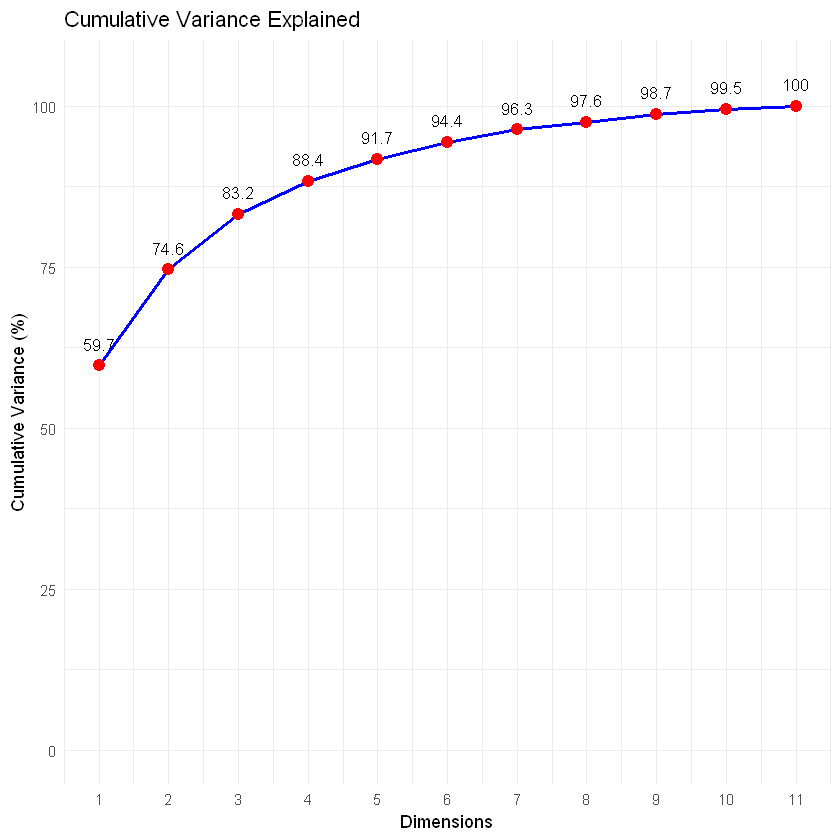

In [ ]:
eig.key_subgenre <- as.data.frame(get_eig(df.ca.key_subgenre))
eig.key_subgenre$dimension <- 1:nrow(eig.key_subgenre)


ggplot(eig.key_subgenre, aes(x = dimension, y = cumulative.variance.percent)) +
  geom_line(color = "blue", linewidth = 1) + 
  geom_point(color = "red", size = 3) +
  geom_text(aes(label = round(cumulative.variance.percent, 1)), 
            vjust = -1.2, 
            size = 3.5) +
  scale_x_continuous(breaks = eig.key_subgenre$dimension) + 
  labs(title = "Cumulative Variance Explained",
       x = "Dimensions",
       y = "Cumulative Variance (%)") +
  theme_minimal() +
  ylim(0, 105) 

Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."


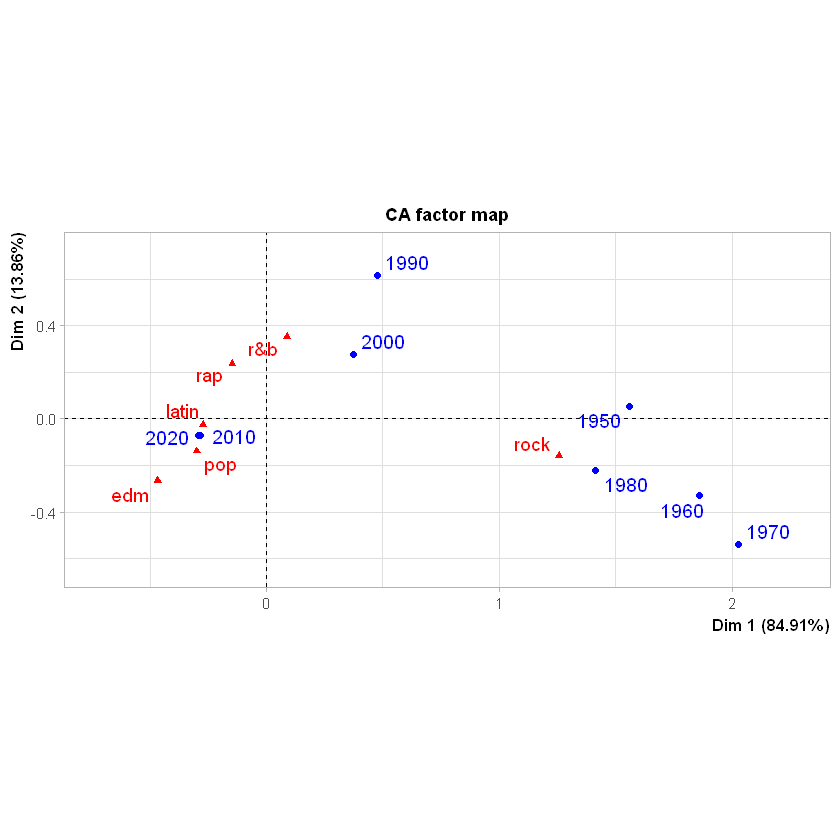

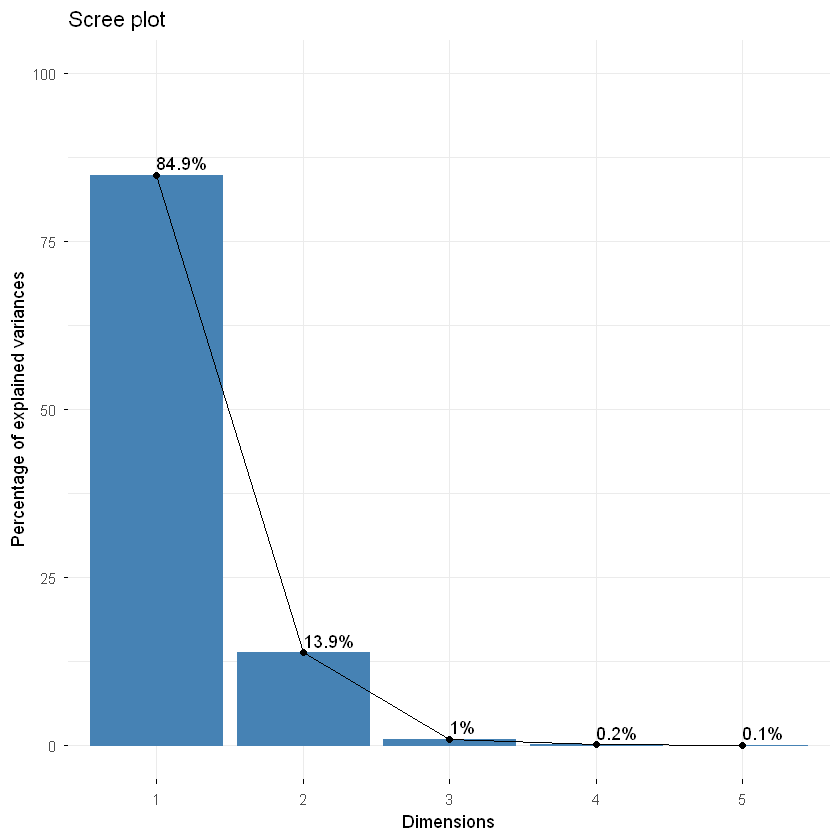

In [52]:
table.year_genre <- table(cat_df$year, cat_df$playlist_genre)
df.ca.year_genre <- CA(table.year_genre, graph = TRUE)
fviz_screeplot(df.ca.year_genre, addlabels = TRUE, ylim = c(0, 100),repel = TRUE)

Warning message:
"ggrepel: 17 unlabeled data points (too many overlaps). Consider increasing max.overlaps"


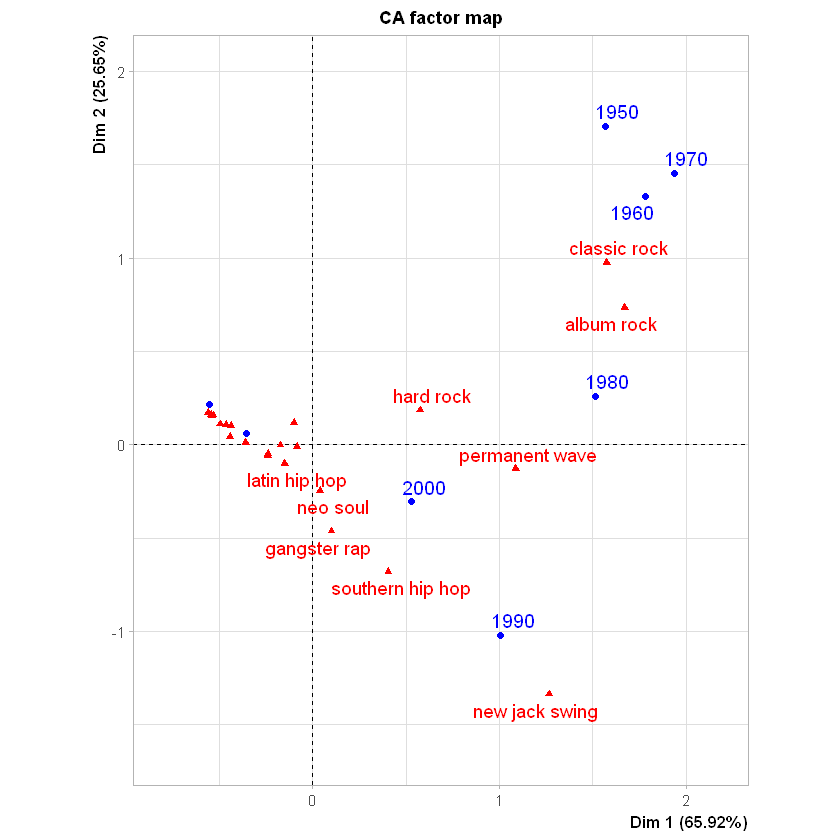

In [ ]:
table.year_subgenre <- table(cat_df$year, cat_df$playlist_subgenre)
df.ca.year_subgenre <- CA(table.year_subgenre, graph = TRUE)


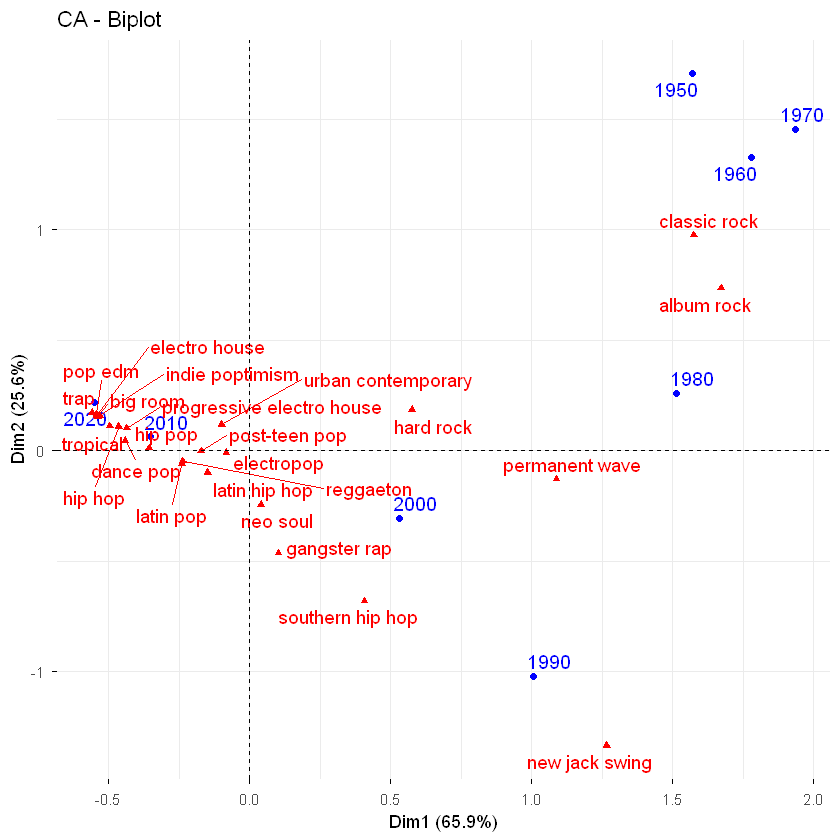

In [57]:
fviz_ca_biplot(df.ca.year_subgenre, repel = TRUE)

Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."


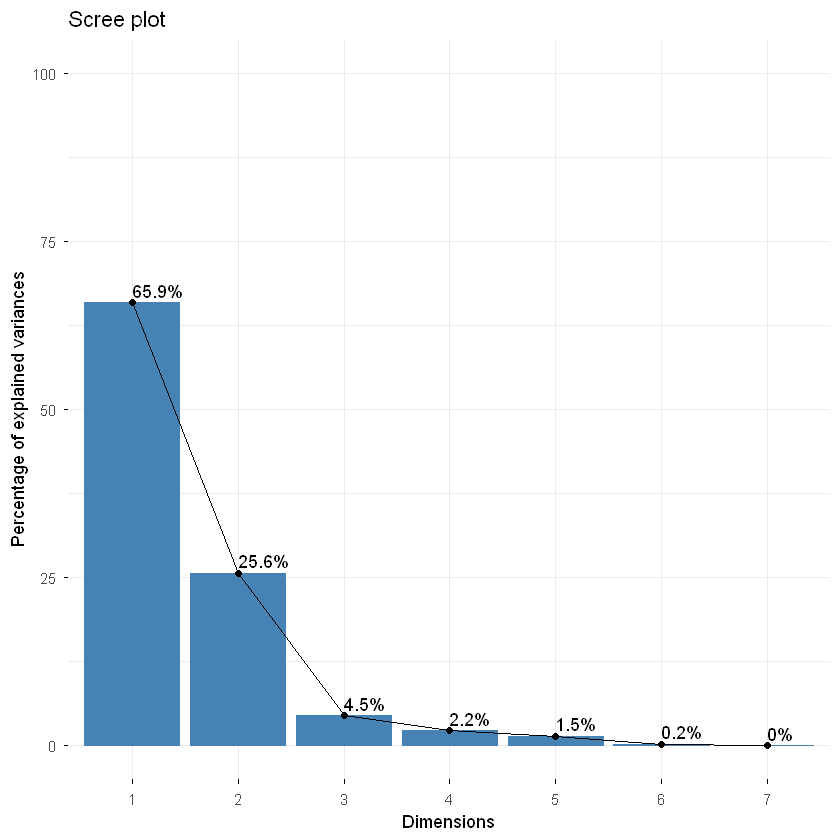

In [56]:
fviz_screeplot(df.ca.year_subgenre, addlabels = TRUE, ylim = c(0, 100),repel = TRUE)

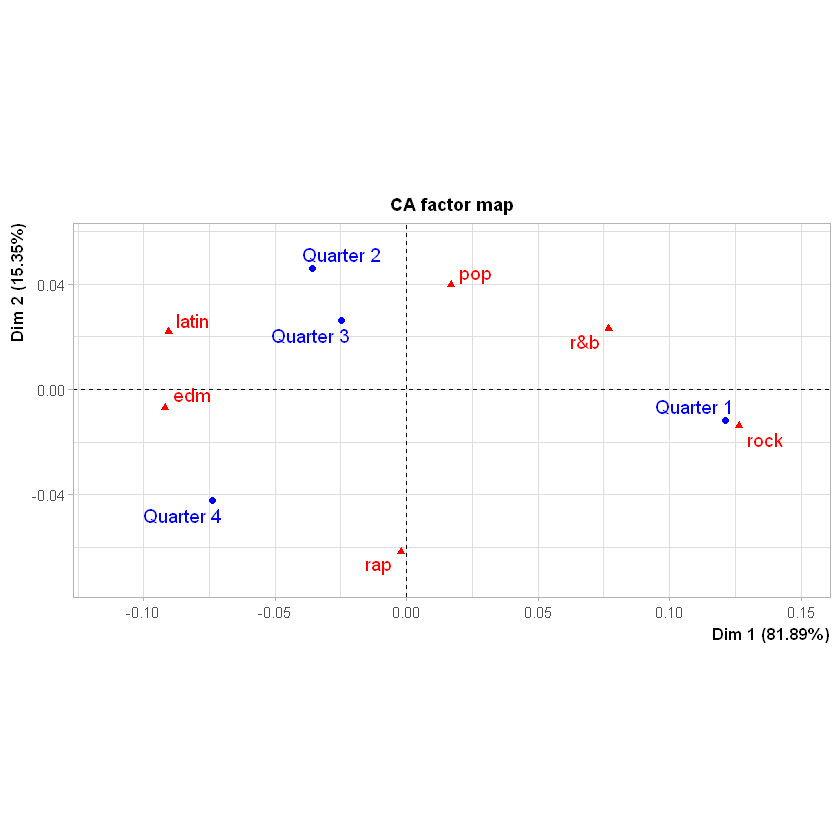

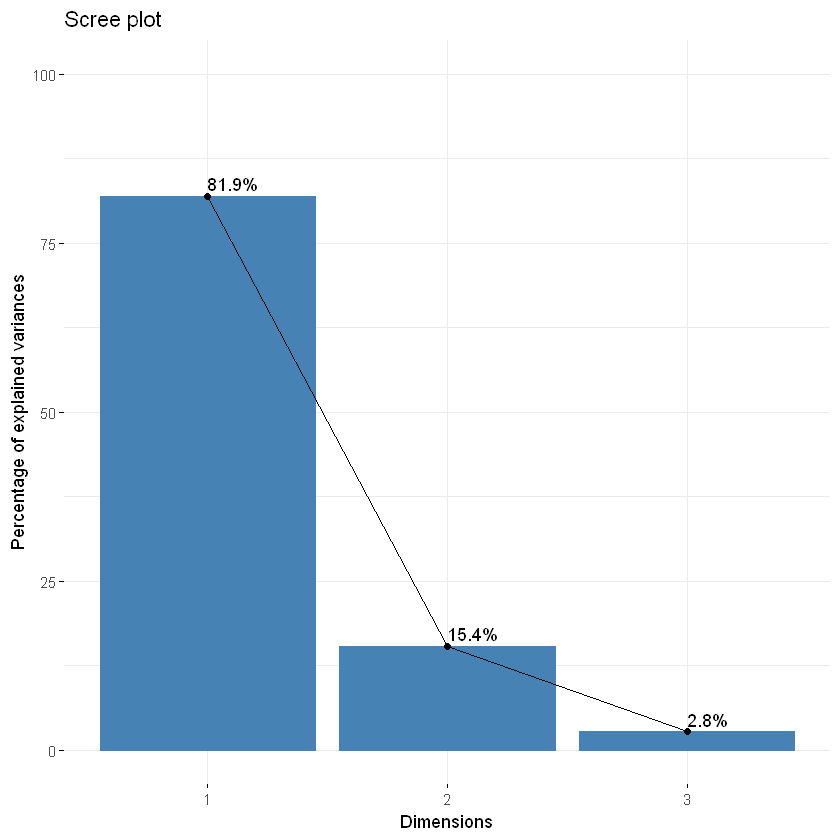

In [ ]:
table.quarter_genre <- table(cat_df$quarter, cat_df$playlist_genre)
df.ca.quarter_genre <- CA(table.quarter_genre, graph = TRUE)
fviz_screeplot(df.ca.quarter_genre, addlabels = TRUE, ylim = c(0, 100),repel = TRUE)

Warning message:
"ggrepel: 1 unlabeled data points (too many overlaps). Consider increasing max.overlaps"


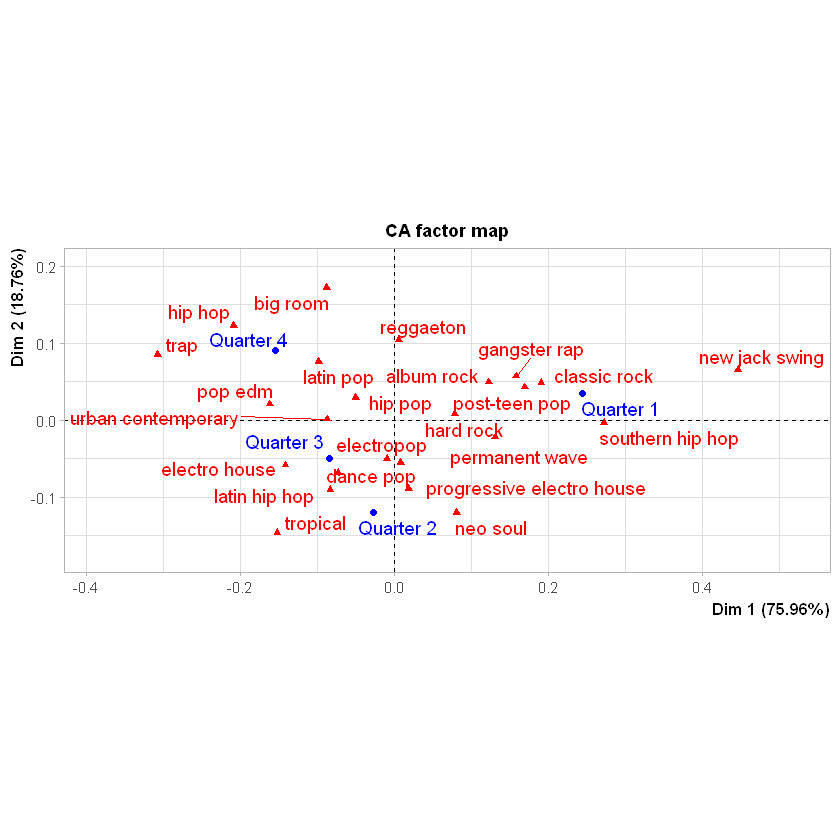

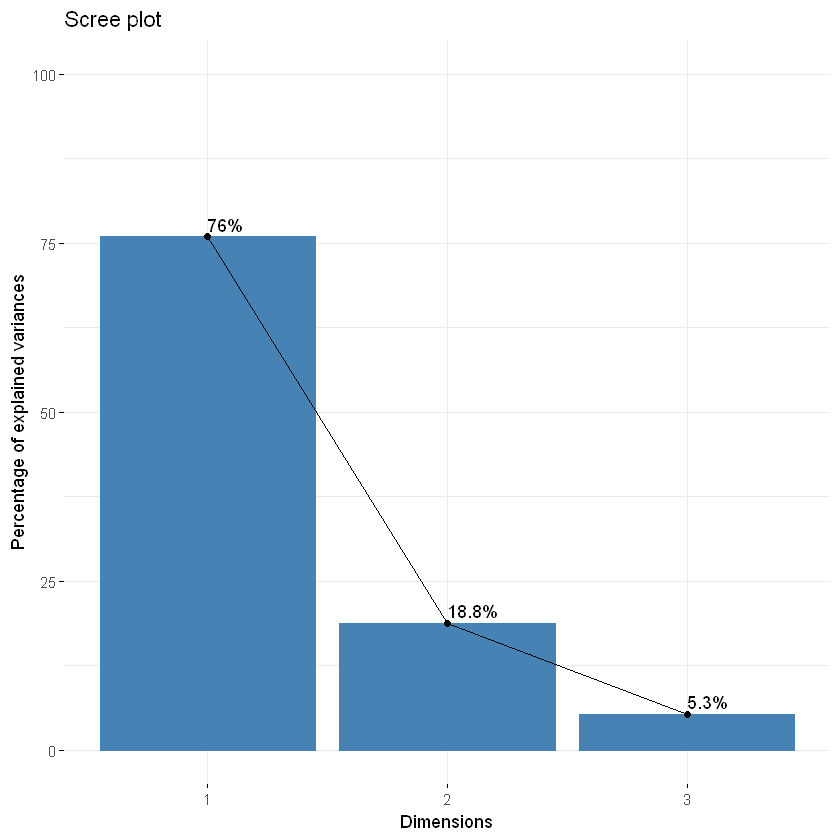

In [ ]:
table.quarter_subgenre <- table(cat_df$quarter, cat_df$playlist_subgenre)
df.ca.quarter_subgenre <- CA(table.quarter_subgenre, graph = TRUE)
fviz_screeplot(df.ca.quarter_subgenre, addlabels = TRUE, ylim = c(0, 100),repel = TRUE)

Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."


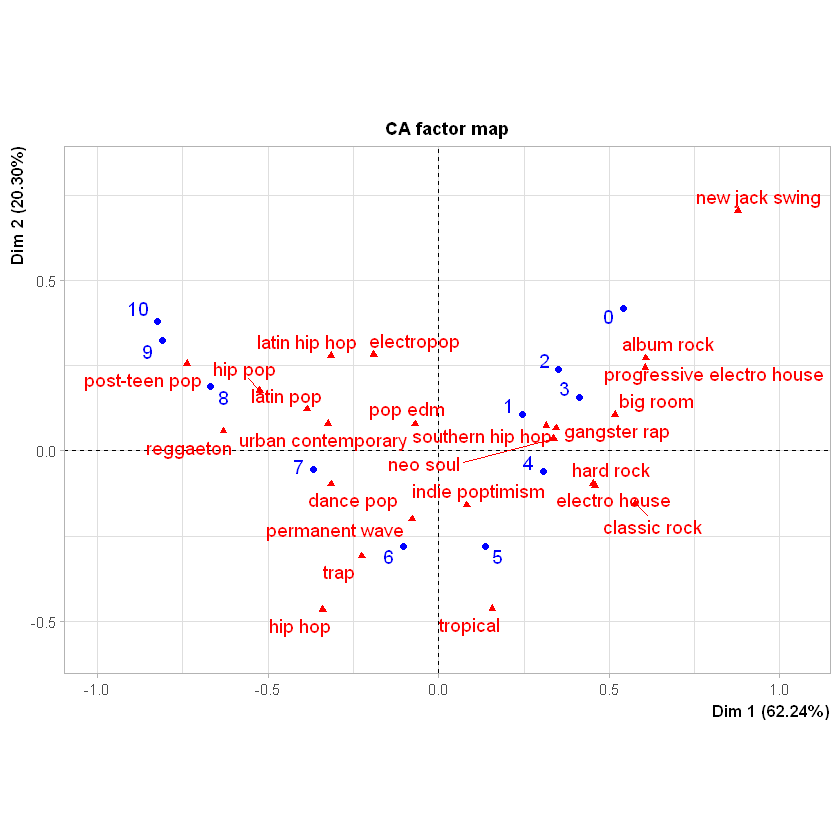

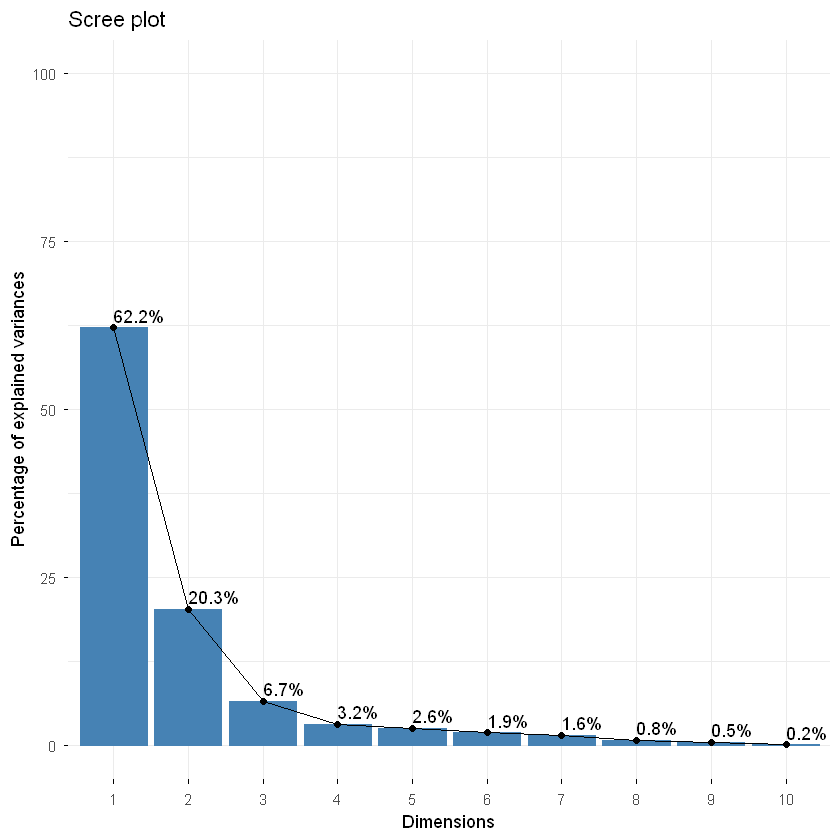

In [108]:
table.quarter_subgenre <- table(cat_df[cat_df$year == 2020 | cat_df$year == 2010,]$factor_popularity, cat_df[cat_df$year == 2020 | cat_df$year == 2010,]$playlist_subgenre)
df.ca.quarter_subgenre <- CA(table.quarter_subgenre, graph = TRUE)
fviz_screeplot(df.ca.quarter_subgenre, addlabels = TRUE, ylim = c(0, 100),repel = TRUE)

Warning message in CA(table.quarter_subgenre, graph = TRUE):
"The rows 10 sum at 0. They were suppressed from the analysis"
Warning message in CA(table.quarter_subgenre, graph = TRUE):
"The columns pop edm, trap sum at 0. They were suppressed from the analysis"
Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."


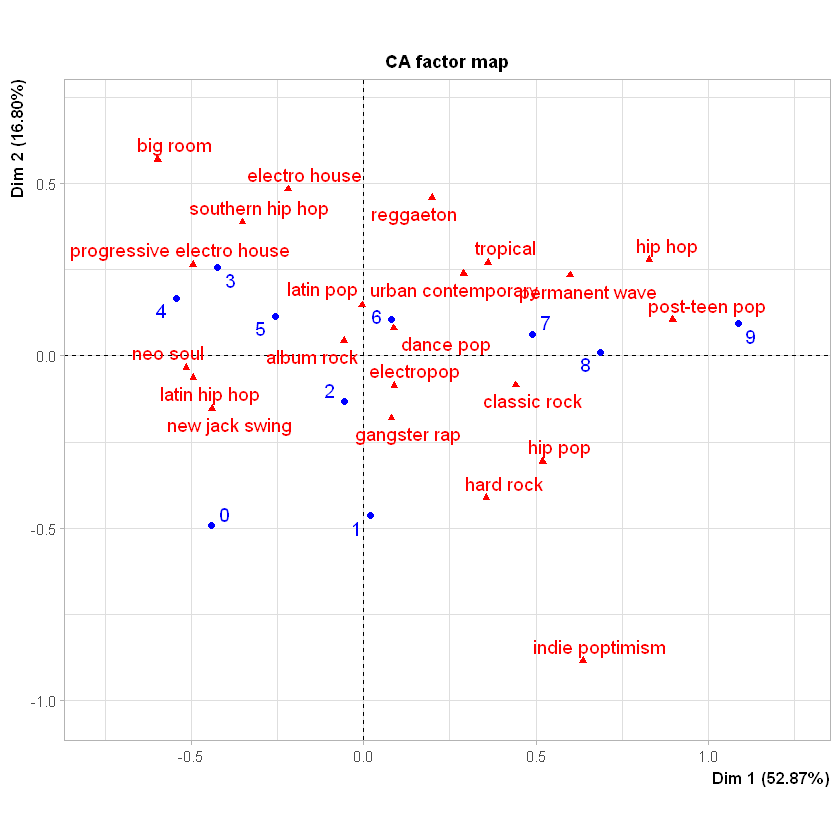

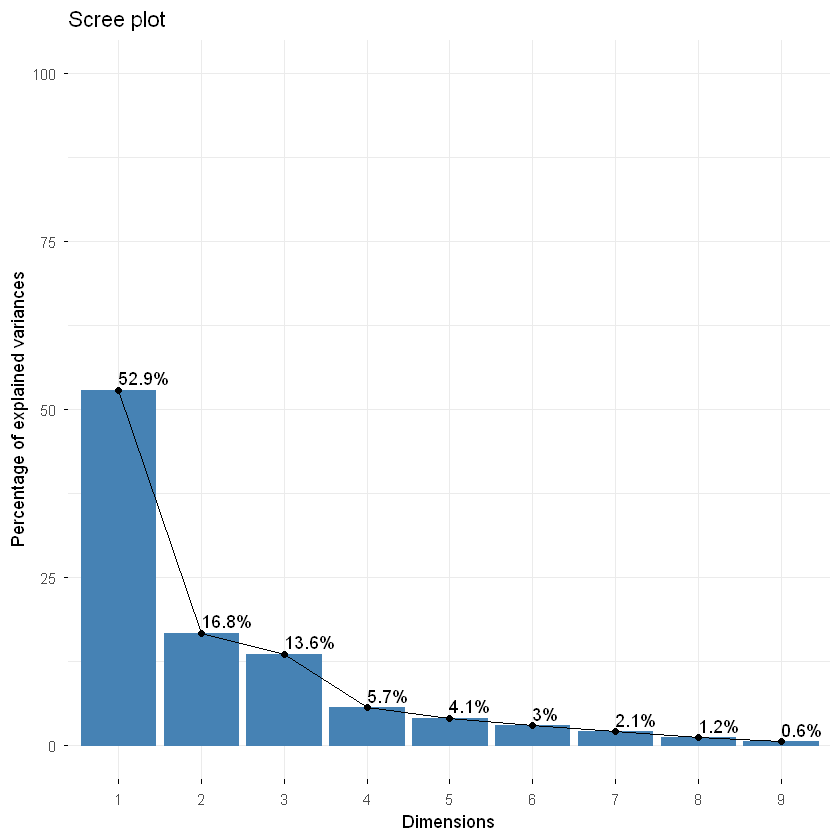

In [109]:
table.quarter_subgenre <- table(cat_df[cat_df$year == 1980 | cat_df$year == 1990,]$factor_popularity, cat_df[cat_df$year == 1980 | cat_df$year == 1990,]$playlist_subgenre)
df.ca.quarter_subgenre <- CA(table.quarter_subgenre, graph = TRUE)
fviz_screeplot(df.ca.quarter_subgenre, addlabels = TRUE, ylim = c(0, 100),repel = TRUE)

Warning message in CA(table.quarter_subgenre, graph = TRUE):
"The rows 10 sum at 0. They were suppressed from the analysis"
Warning message in CA(table.quarter_subgenre, graph = TRUE):
"The columns big room, dance pop, electro house, gangster rap, hip hop, hip pop, indie poptimism, pop edm, reggaeton, trap, tropical sum at 0. They were suppressed from the analysis"
Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."


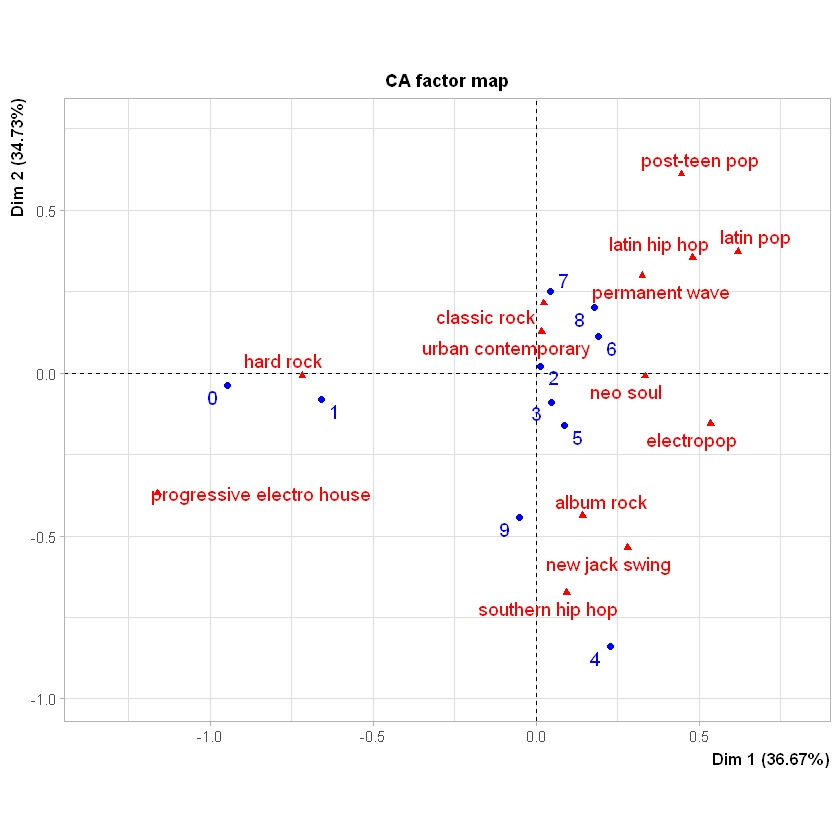

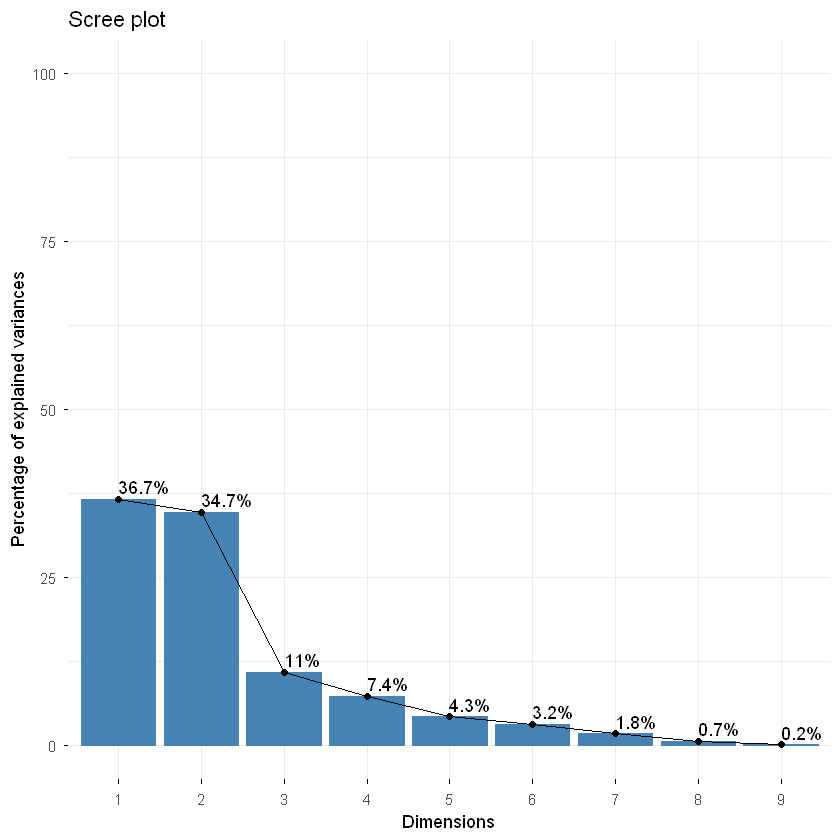

In [110]:
table.quarter_subgenre <- table(cat_df[cat_df$year == 1960 | cat_df$year == 1970,]$factor_popularity, cat_df[cat_df$year == 1960 | cat_df$year == 1970,]$playlist_subgenre)
df.ca.quarter_subgenre <- CA(table.quarter_subgenre, graph = TRUE)
fviz_screeplot(df.ca.quarter_subgenre, addlabels = TRUE, ylim = c(0, 100),repel = TRUE)

Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."


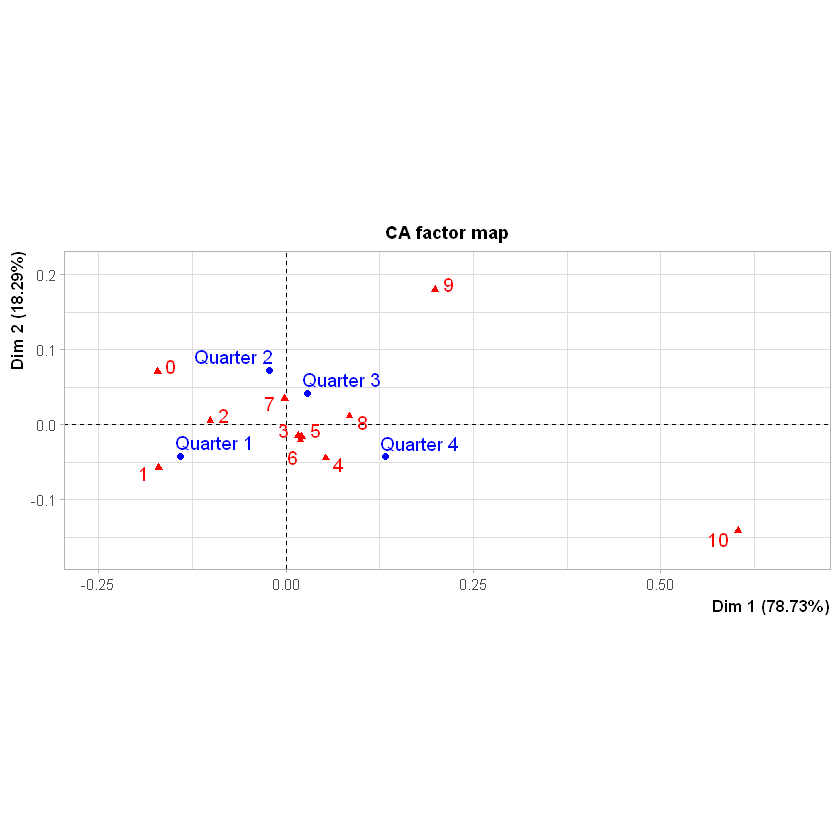

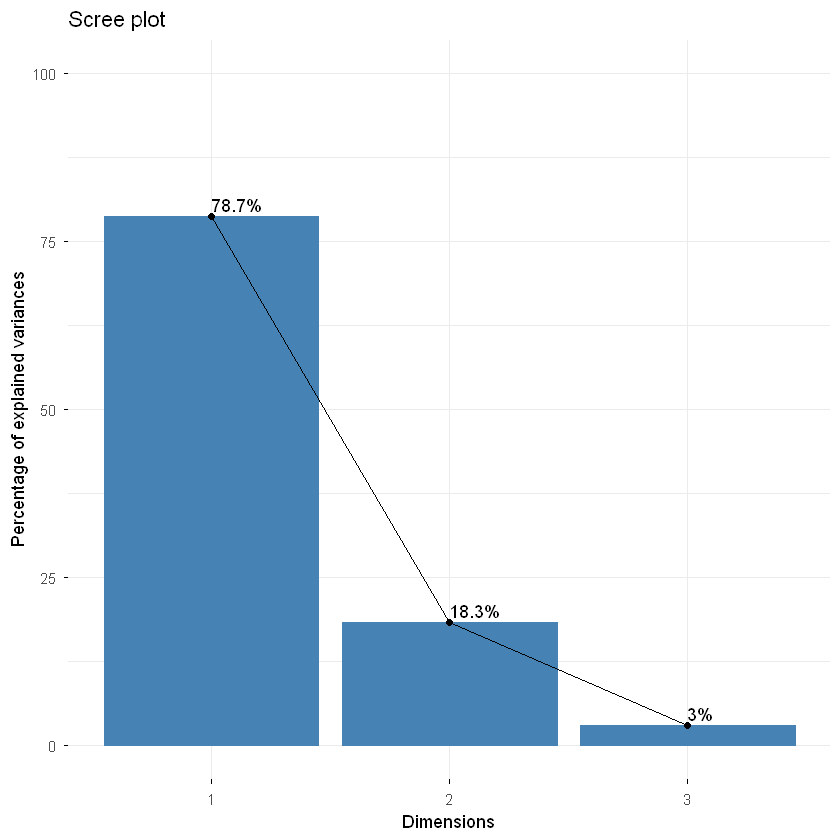

In [93]:
table.quarter_popularity <- table(cat_df$quarter, cat_df$factor_popularity)
df.ca.quarter_popularity <- CA(table.quarter_popularity, graph = TRUE)
fviz_screeplot(df.ca.quarter_popularity, addlabels = TRUE, ylim = c(0, 100),repel = TRUE)

In [96]:
summary(cat_df$factor_popularity)

0    1    2    3    4    5    6    7    8    9   10 
2703 2714 2012 2579 4166 4697 5020 4518 3084 1088  252

Length  Class   Mode 
     0   NULL   NULL 

Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."


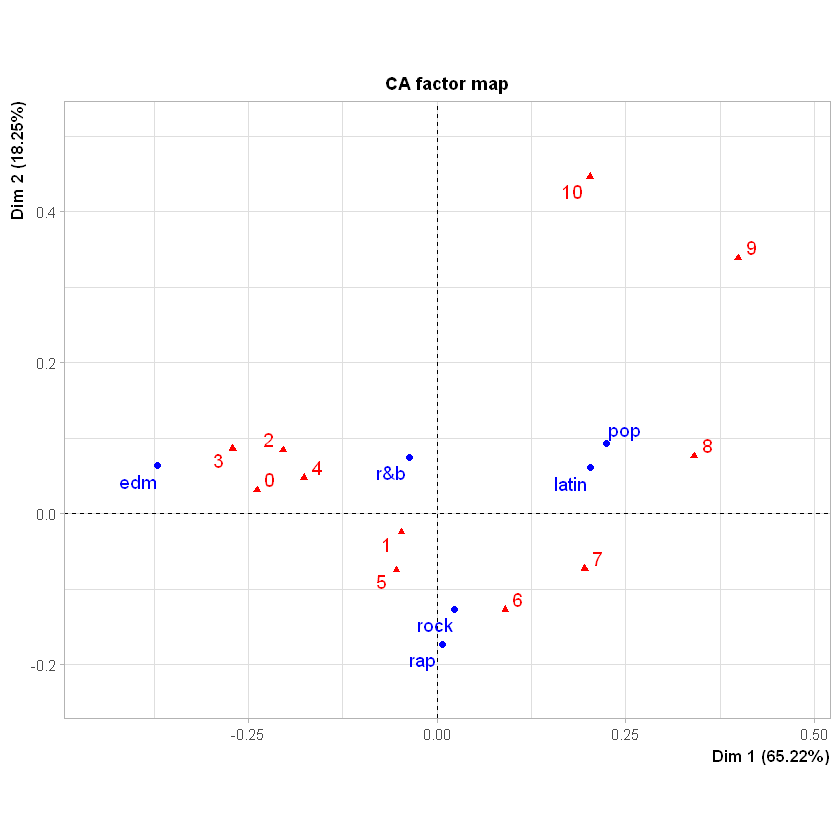

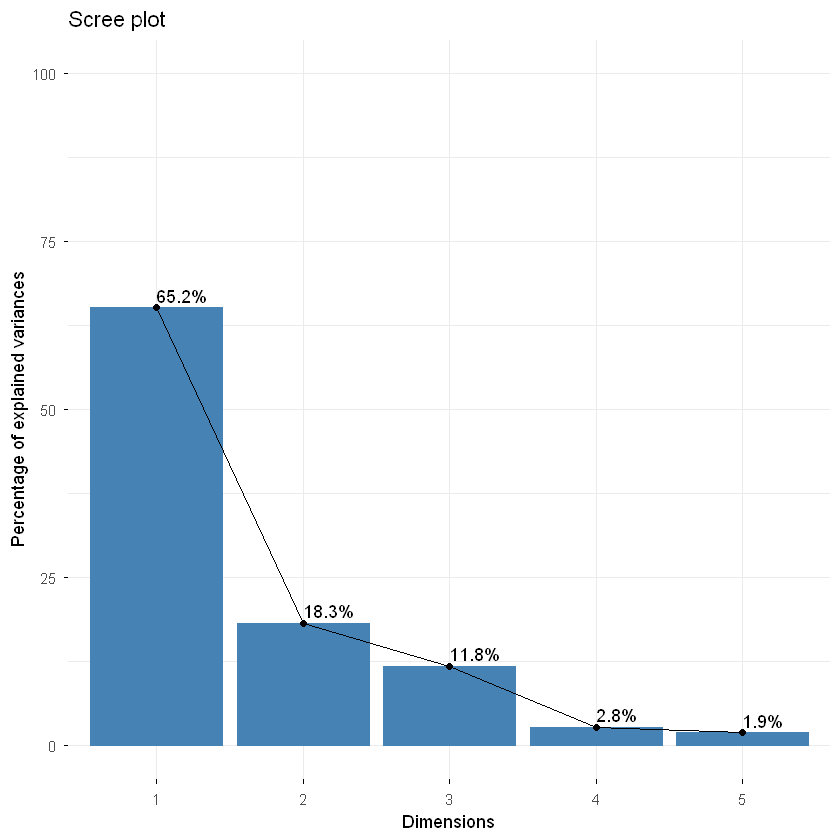

In [101]:
table.genre_popularity <- table(cat_df$playlist_genre, cat_df$factor_popularity)
df.ca.genre_popularity <- CA(table.genre_popularity, graph = TRUE)
fviz_screeplot(df.ca.genre_popularity, addlabels = TRUE, ylim = c(0, 100),repel = TRUE)

In [85]:
cat_df.sub <- subset(cat_df, select = -c(playlist_subgenre, bool_instrumentalness,month))

In [86]:
df.mca <- MCA(cat_df.sub, graph = TRUE)
print(df.mca)

Warning message:
"ggrepel: 14 unlabeled data points (too many overlaps). Consider increasing max.overlaps"


**Results of the Multiple Correspondence Analysis (MCA)**
The analysis was performed on 32833 individuals, described by 6 variables
*The results are available in the following objects:

   name              description                       
1  "$eig"            "eigenvalues"                     
2  "$var"            "results for the variables"       
3  "$var$coord"      "coord. of the categories"        
4  "$var$cos2"       "cos2 for the categories"         
5  "$var$contrib"    "contributions of the categories" 
6  "$var$v.test"     "v-test for the categories"       
7  "$var$eta2"       "coord. of variables"             
8  "$ind"            "results for the individuals"     
9  "$ind$coord"      "coord. for the individuals"      
10 "$ind$cos2"       "cos2 for the individuals"        
11 "$ind$contrib"    "contributions of the individuals"
12 "$call"           "intermediate results"            
13 "$call$marge.col" "weights of columns"              
14 "$call$marge.li"  "weights 

In [87]:
df.mca$eig

,eigenvalue,percentage of variance,cumulative percentage of variance
dim 1,0.31318038,4.944953,4.944953
dim 2,0.23353295,3.687362,8.632316
dim 3,0.21307434,3.364332,11.996647
dim 4,0.20314421,3.207540,15.204188
dim 5,0.20011878,3.159770,18.363958
dim 6,0.19404491,3.063867,21.427825
dim 7,0.18455932,2.914095,24.341920
dim 8,0.17872512,2.821976,27.163895
dim 9,0.17661342,2.788633,29.952528
dim 10,0.17302108,2.731912,32.684440


Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."


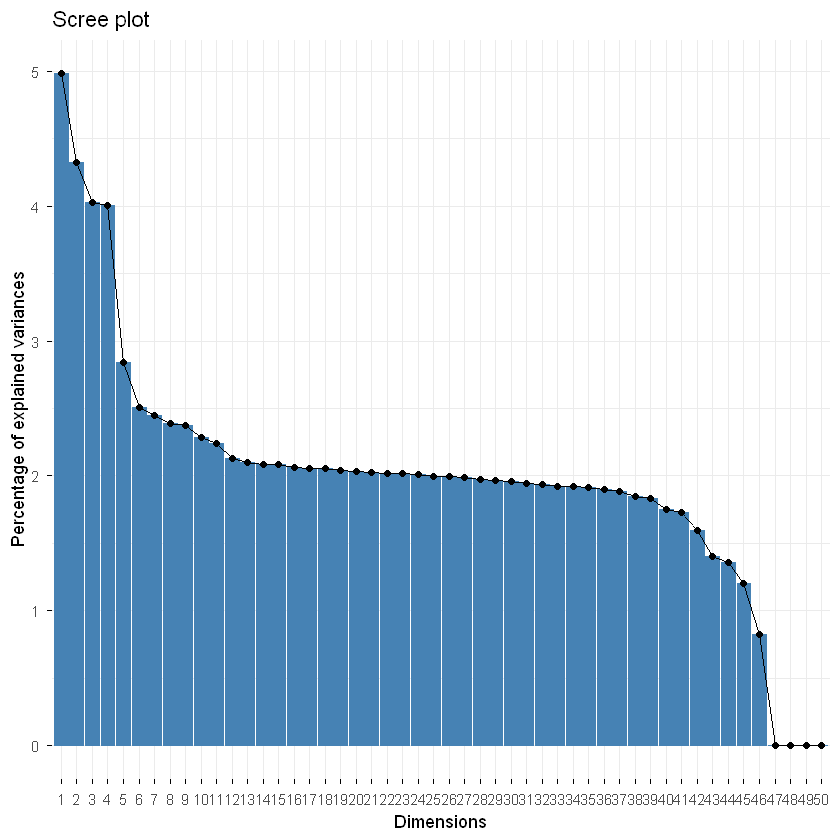

In [82]:
fviz_screeplot(df.mca, addlabels = FALSE,ncp = 54)

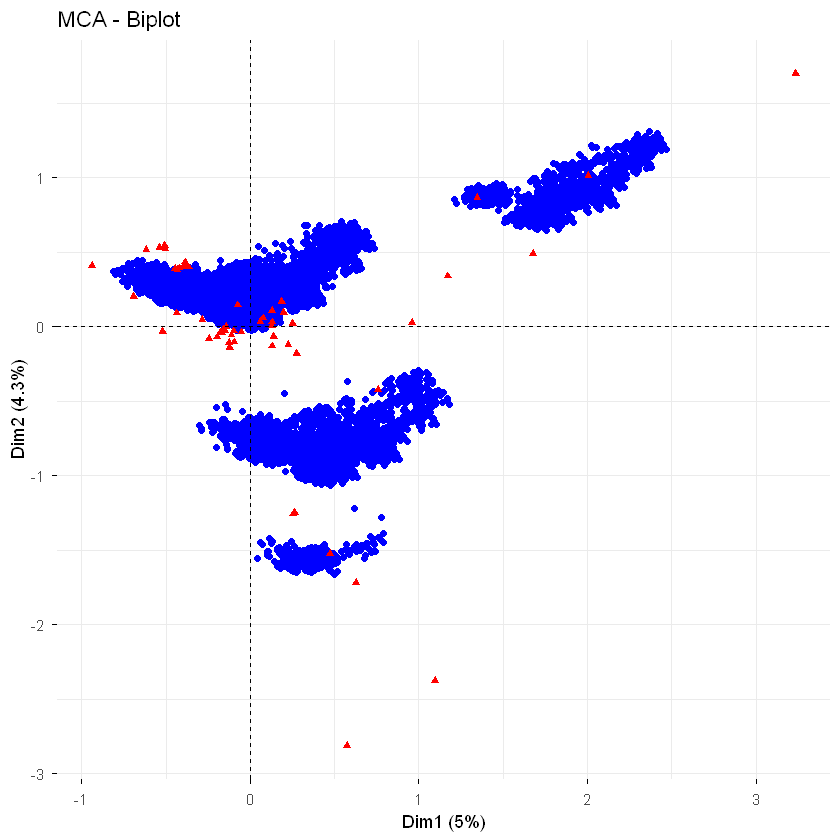

In [83]:
fviz_mca_biplot(df.mca, label = "none", ggtheme = theme_minimal())

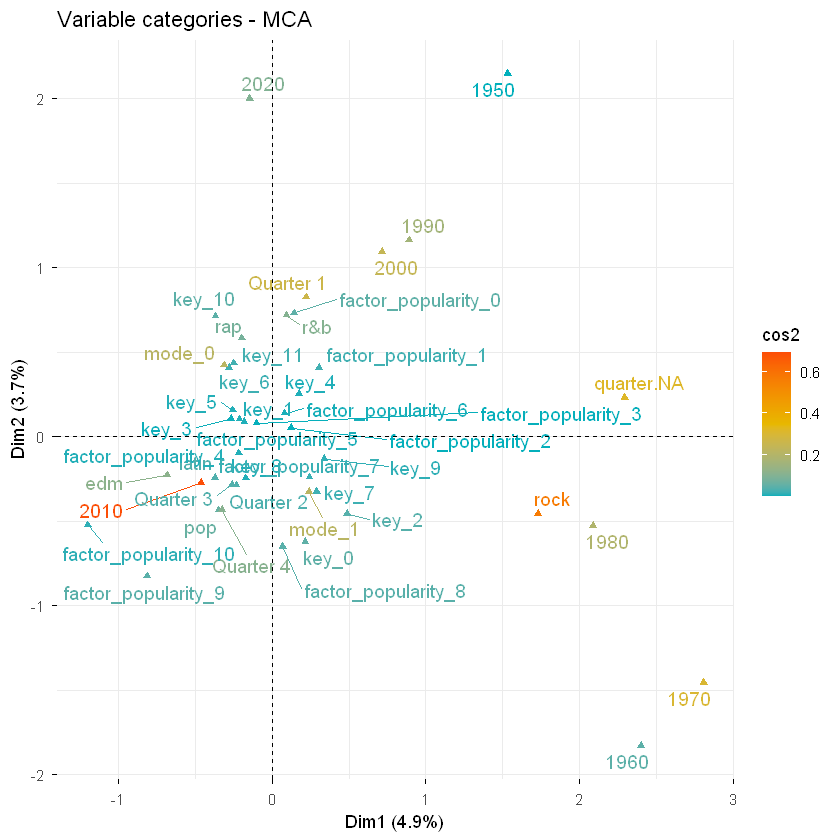

In [88]:
fviz_mca_var(df.mca, col.var = "cos2", gradient.cols = c("#00AFBB", "#E7B800", "#FC4E07"), repel = TRUE)

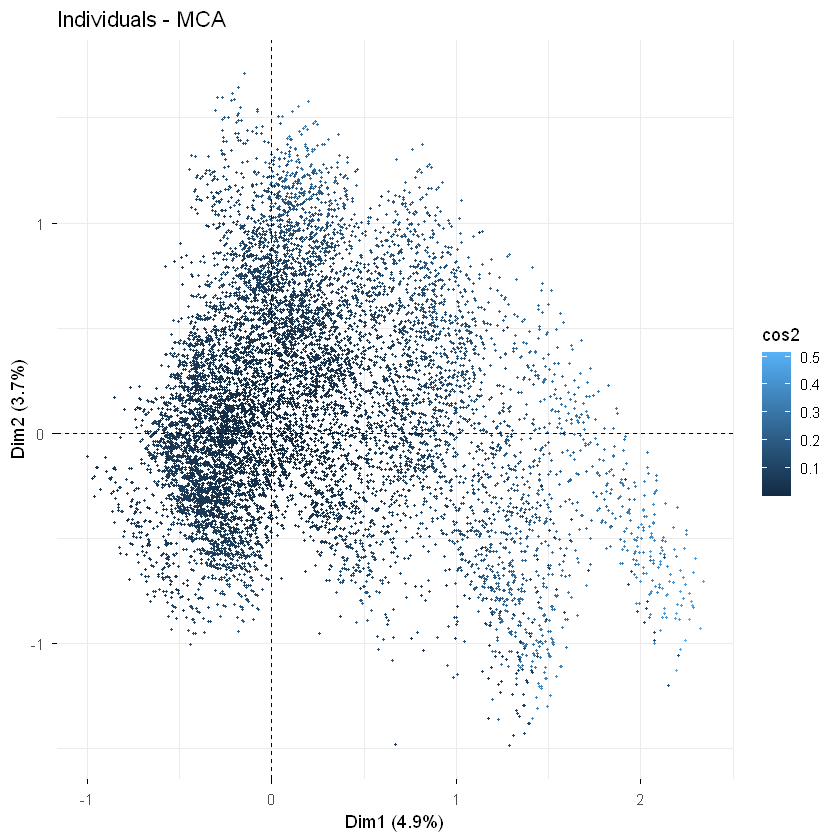

In [89]:
fviz_mca_ind(df.mca, col.ind = "cos2", label = "none", pointsize = 0.5, ggtheme = theme_minimal())

In [90]:
df.sub <- subset(df, select = c(num_vars,cat_vars))
df.sub <- subset(df.sub, select = -c(bool_instrumentalness))

In [61]:
summary(df.sub)

 track_popularity  danceability        energy            loudness      
 Min.   :  0.00   Min.   :0.0000   Min.   :0.000175   Min.   :-46.448  
 1st Qu.: 24.00   1st Qu.:0.5630   1st Qu.:0.581000   1st Qu.: -8.171  
 Median : 45.00   Median :0.6720   Median :0.721000   Median : -6.166  
 Mean   : 42.48   Mean   :0.6548   Mean   :0.698619   Mean   : -6.720  
 3rd Qu.: 62.00   3rd Qu.:0.7610   3rd Qu.:0.840000   3rd Qu.: -4.645  
 Max.   :100.00   Max.   :0.9830   Max.   :1.000000   Max.   :  1.275  
                                                                       
  speechiness      acousticness    instrumentalness       liveness     
 Min.   :0.0000   Min.   :0.0000   Min.   :0.0000000   Min.   :0.0000  
 1st Qu.:0.0410   1st Qu.:0.0151   1st Qu.:0.0000000   1st Qu.:0.0927  
 Median :0.0625   Median :0.0804   Median :0.0000161   Median :0.1270  
 Mean   :0.1071   Mean   :0.1753   Mean   :0.0847472   Mean   :0.1902  
 3rd Qu.:0.1320   3rd Qu.:0.2550   3rd Qu.:0.0048300   3rd Qu.:0

In [91]:
df.sub$quarter <- addNA(df.sub$quarter)

In [92]:
df.mfa <- FAMD(df.sub)

Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_text_repel()`)."
Warning message:
"ggrepel: 32833 unlabeled data points (too many overlaps). Consider increasing max.overlaps"
Warning message:
"ggrepel: 46 unlabeled data points (too many overlaps). Consider increasing max.overlaps"
Warning message:
"ggrepel: 32833 unlabeled data points (too many overlaps). Consider increasing max.overlaps"
Warning message:
"ggrepel: 5 unlabeled data points (too many overlaps). Consider increasing max.overlaps"
Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_text_repel()`)."
Warning message:
"ggrepel: 32 unlabeled data points (too many overlaps). Consider increasing max.overlaps"
